# Recovering Rebar Geometry from Ground-Penetrating Radar
## A Source-Profiled, Confidence-Aware Full-Waveform Inversion Pipeline

**Research Progress Report, Version 3**  
**Snapshot date:** June 1, 2026  
**Experiment evidence scope:** `outputs/experiments/001_*` through `outputs/experiments/283_*`

---

### Scope Note

This version is rebuilt around the numbered experiment archive. All embedded figures, animations, and traceability rows come from `outputs/experiments`.

### Abstract

We present a two-dimensional computational pipeline for recovering steel rebar location, depth, and radius from ground-penetrating radar (GPR) B-scans. The system uses finite-difference time-domain (FDTD) electromagnetic simulation, full-waveform candidate evaluation, source-pulse nuisance fitting, staged coordinate updates, and confidence-aware reporting.

The central finding is that rebar position is comparatively robust, while radius is sensitive to source-wavelet mismatch, grid rasterization, nearby bars, and acquisition geometry. The experiment archive documents the progression from single-rebar recovery to multi-rebar ambiguity reporting, detector-seeded refinement, variable-radius close-spacing scenes, and acquisition-aware inversion. The latest completed branch shows that a four-source local scan with 40 mm transmitter/receiver offset resolves the hard close-50 mm target across three noise seeds, with six strong confidence rows and zero reported ambiguity width.


## Executive Summary

**What we built.** We built a physics-based GPR simulation and inversion workflow that predicts radar echoes from rebar geometry and then uses those echoes to recover bar position, depth, and radius.

**Where the work began.** The numbered archive starts with controlled single-rebar inversions and radius profiles. Those runs established that position and depth can be recovered reliably, while radius requires explicit local polishing and careful reporting.

**What the campaign discovered.** The largest early radius failure was not simply cycle-skipping, material uncertainty, or a need for heavier neural parameterization. It was source-wavelet mismatch: modest errors in pulse amplitude, timing, or center frequency can be absorbed as a wrong radius unless the pulse is fitted jointly with geometry.

**Where the work stands now.** The current pipeline detects candidate bars from B-scans, assigns one seed per physical target, corrects position before estimating size, fits source-pulse nuisance parameters, and reports confidence labels and ambiguity intervals. The current frontier is acquisition design for closely spaced variable-radius bars.


## Terms Used in This Report

| Term | Meaning in this project |
|---|---|
| GPR | Ground-penetrating radar: a surface antenna transmits electromagnetic pulses and records echoes from subsurface objects. |
| B-scan | A 2-D radar image: horizontal axis is antenna position, vertical axis is travel time, and pixel intensity is echo amplitude. |
| FDTD | Finite-difference time-domain: a grid-based method for simulating electromagnetic wave propagation over time. |
| FWI | Full-waveform inversion: fitting the entire waveform, not just picked arrival times, to infer model parameters. |
| Source profiling | Fitting small nuisance parameters of the radar pulse, namely amplitude, time shift, and center-frequency scale. |
| Confidence margin | The objective gap between the best candidate and the next distinct competing candidate. |
| Ambiguity interval | The range of values that the data cannot rule out under the reporting threshold. |
| Tx/Rx offset | The lateral spacing between transmitter and receiver antennas. |


## 1. Baseline Data and Forward Physics From Numbered Experiments

The numbered archive contains the baseline B-scan and model-comparison artifacts needed to explain the data type and the recovery task. A B-scan is created by repeating the FDTD forward solve at multiple antenna positions. Steel bars appear as hyperbolic events because travel time is shortest when the antenna is closest to the bar.

The forward model uses a Yee-grid FDTD update with absorbing boundaries. The experiment archive also contains wavefield animations that show the radar pulse entering the slab, scattering from a bar, and returning to the receiver. These archive-native figures replace the earlier pre-numbered presentation figures.


<figure>
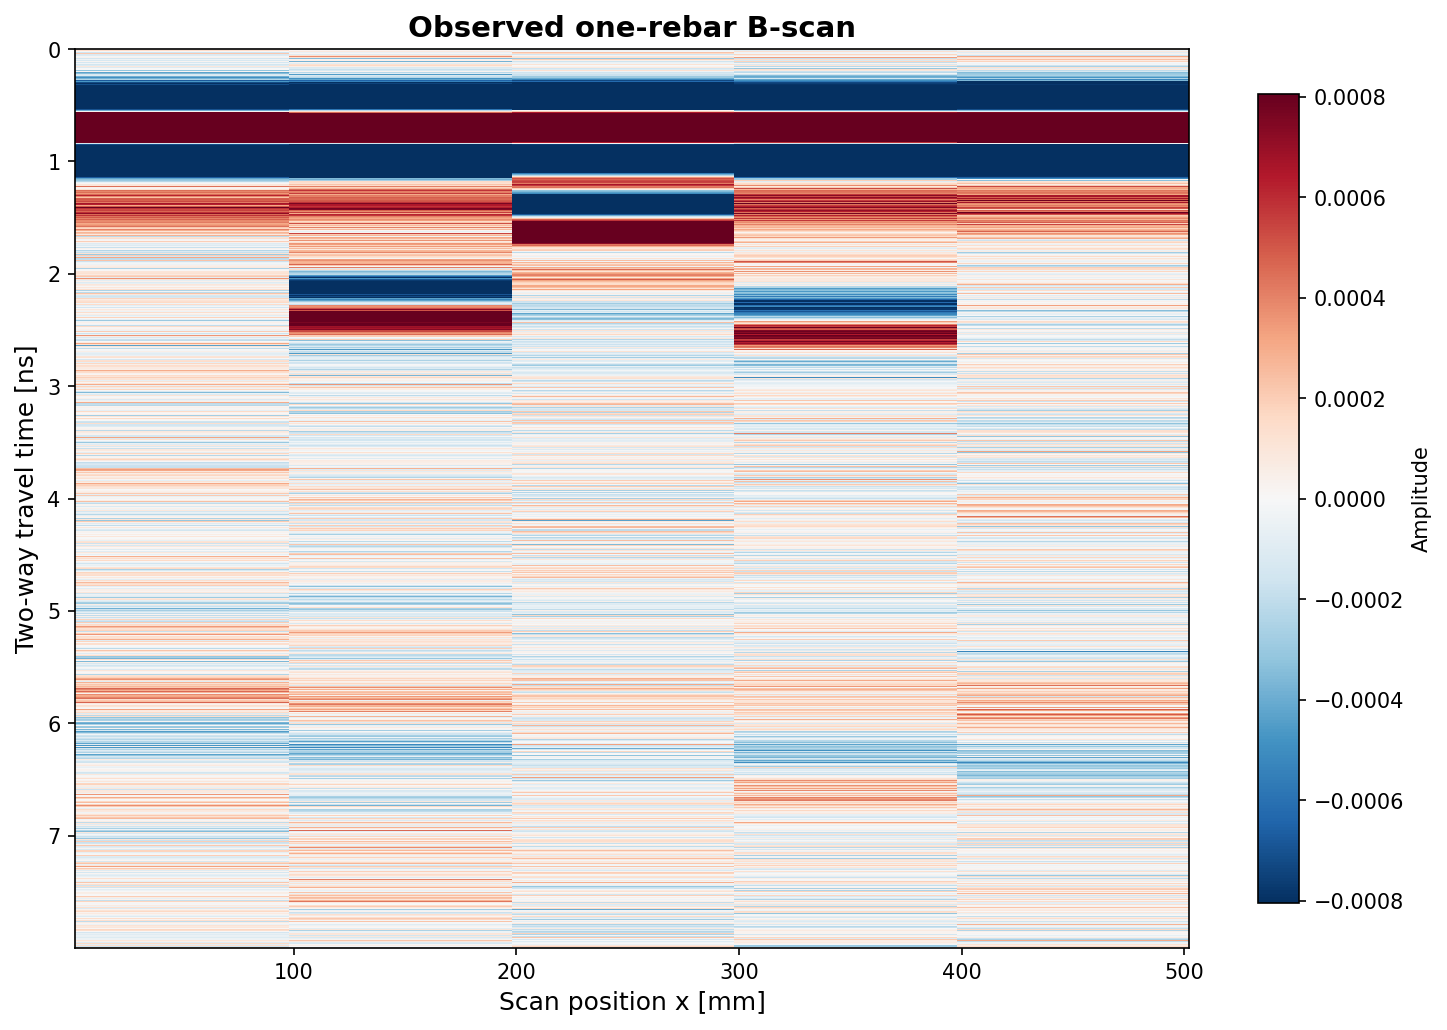<br>
<figcaption><em>Figure 1. Experiment 023 observed B-scan for the single-rebar benchmark under 10 percent noise. This numbered experiment artifact is the baseline radar image used to introduce the data type.</em></figcaption>
</figure>


<figure>
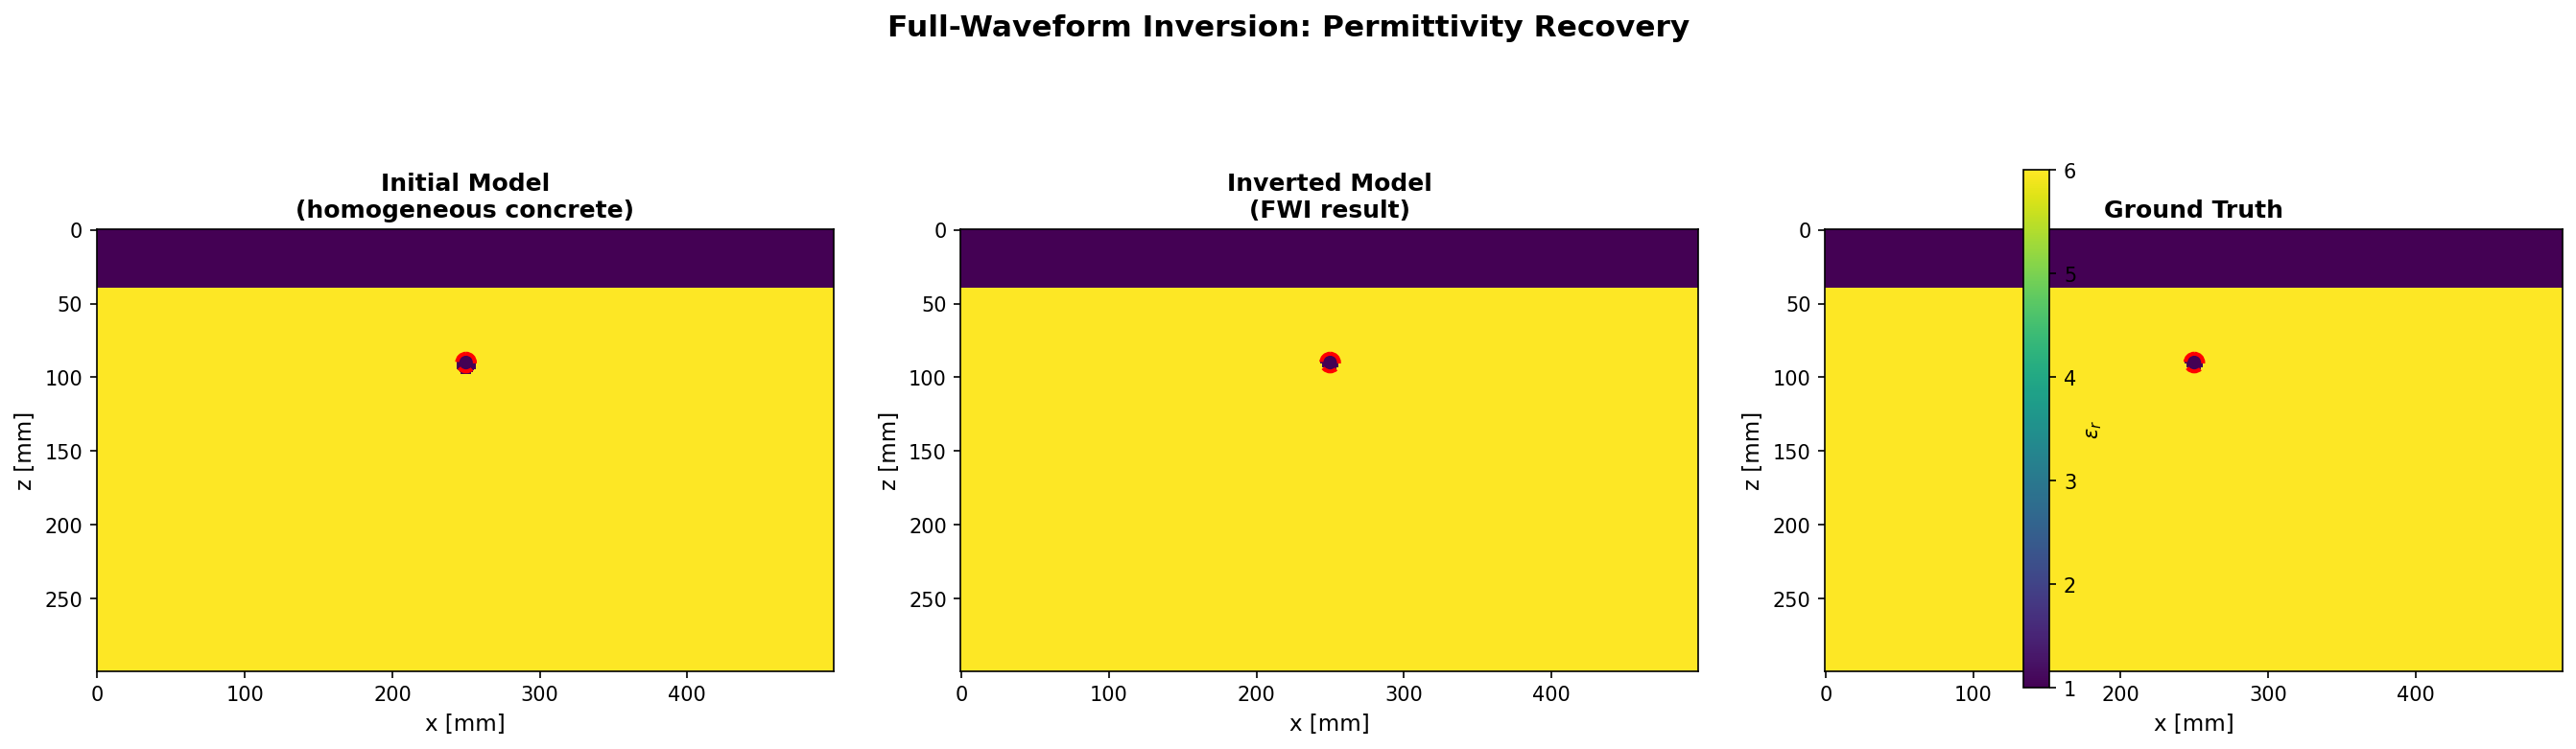<br>
<figcaption><em>Figure 2. Experiment 023 model comparison. The grid-polish branch recovers the single-rebar geometry on the numbered experiment archive rather than relying on pre-numbered presentation figures.</em></figcaption>
</figure>


<figure>
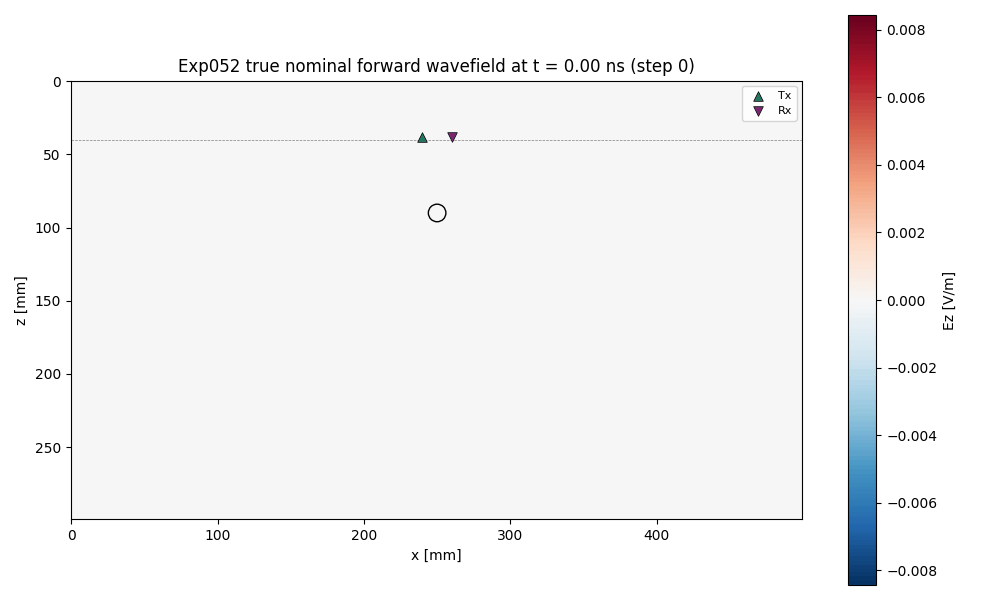<br>
<figcaption><em>Figure 3. Experiment 052 nominal wavefield animation. The pulse propagates through the slab and scatters from the target, illustrating the FDTD forward solve used throughout the campaign.</em></figcaption>
</figure>


<figure>
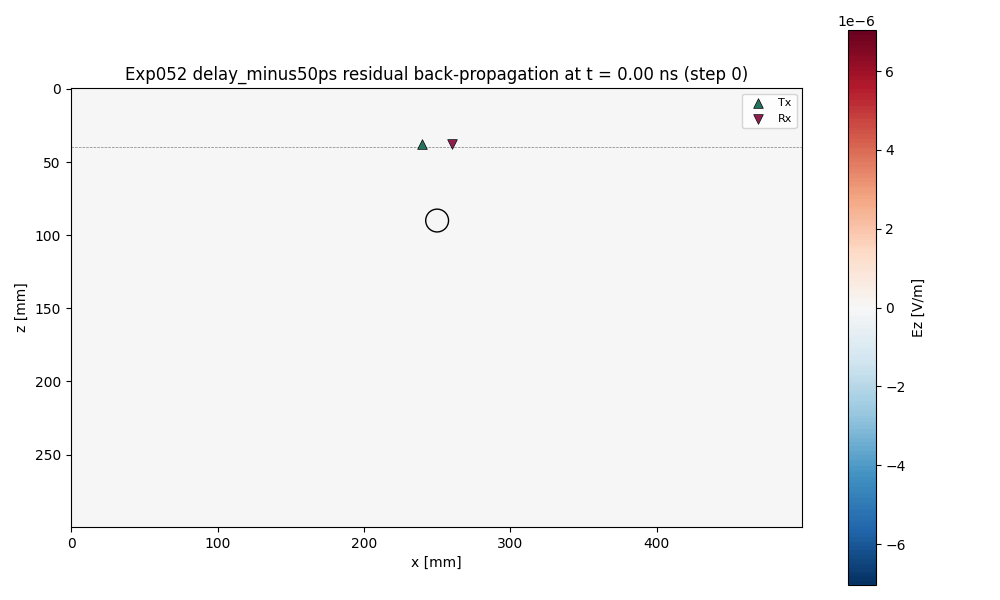<br>
<figcaption><em>Figure 4. Experiment 052 residual back-propagation diagnostic for a mismatched-delay candidate. This shows where waveform residuals carry update information and why timing/source mismatch is handled explicitly.</em></figcaption>
</figure>


## 2. Single-Rebar Milestone and the Radius Problem

Early numbered runs established that the single-rebar location problem is tractable on synthetic data. Experiment 023 is a representative 10 percent noise branch with top-candidate reporting. The result is not only a point estimate; it also illustrates why the archive shifted toward margin and interval reporting.

The main lesson from the early archive is that radius is more delicate than position. Continuous optimization can drift toward a too-thick bar, and nearby radii can occupy identical grid cells after rasterization. A visually plausible B-scan match is therefore not enough. The report therefore states whether the radius is actually separated from nearby alternatives.


## 3. Strategy Tests: What Actually Moves Radius?

The archive tested several published ideas as hypotheses rather than adopting them wholesale.

| Strategy tested | Experiment evidence | Result in this project |
|---|---|---|
| Progressively expanded bandwidth | Experiments 043-045 | Low bands help seed position, but radius information sits mainly in higher-frequency content. |
| Frequency weighting | Experiments 046-047 | Size-sensitive bands need higher weight; equal averaging can dilute radius margins. |
| Wasserstein distance | Experiments 048-051 | Useful for timing-shift diagnostics, but too flat for radius selection because amplitude detail matters. |
| Material tradeoff | Experiment 056 | Material variation does not explain the radius bias at the correct position. |
| Source profiling | Experiments 052-058 | The decisive fix: jointly fit source amplitude, time shift, and center-frequency scale. |


<figure>
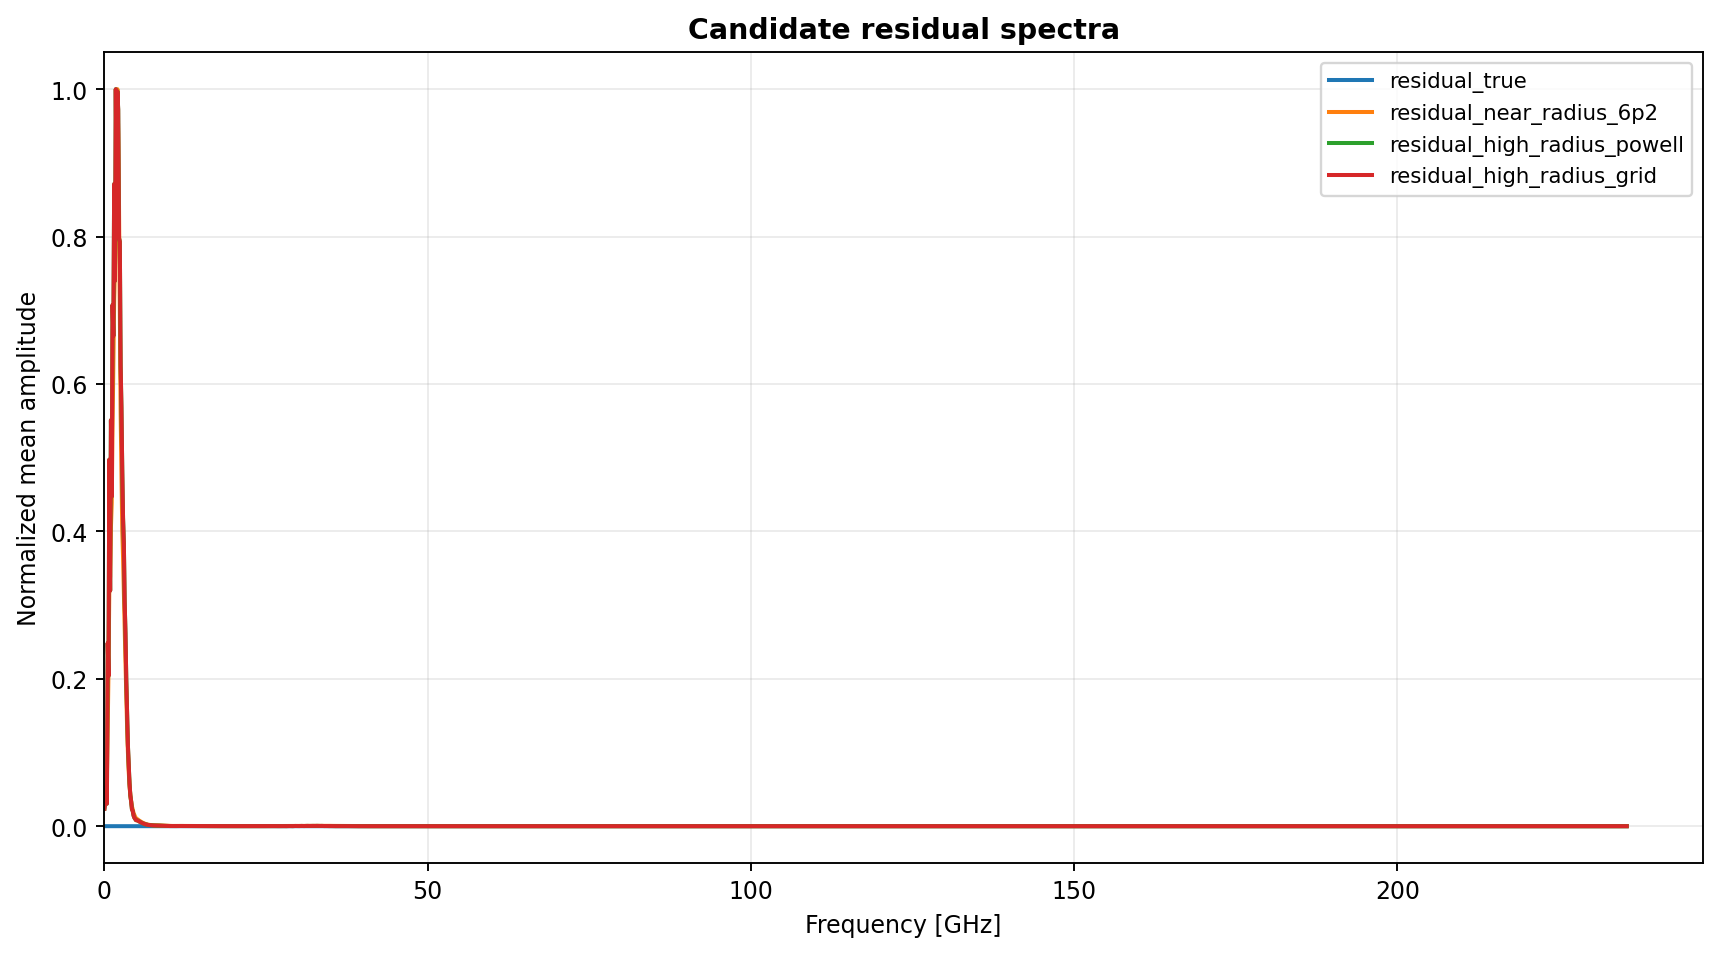<br>
<figcaption><em>Figure 5. Experiment 043 spectrum diagnostic. Radius-discriminating residual energy is concentrated in the higher band, explaining why low-frequency staging helps position more than size.</em></figcaption>
</figure>

<figure>
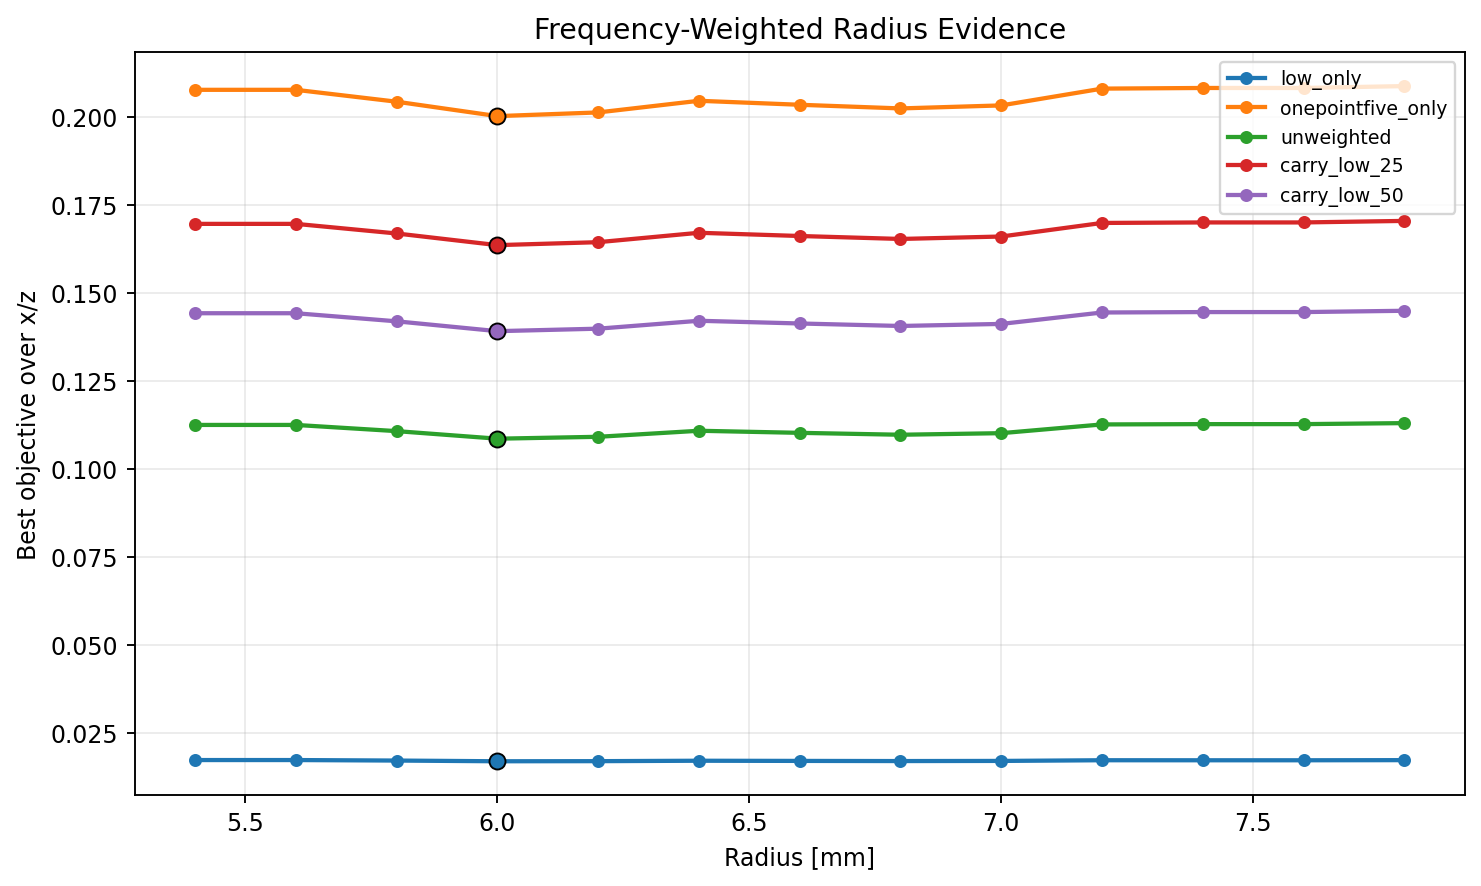<br>
<figcaption><em>Figure 6. Experiment 047 frequency-weighted radius profiles. Equal multi-frequency averaging dilutes radius evidence; selective weighting preserves the size-sensitive signal.</em></figcaption>
</figure>


<figure>
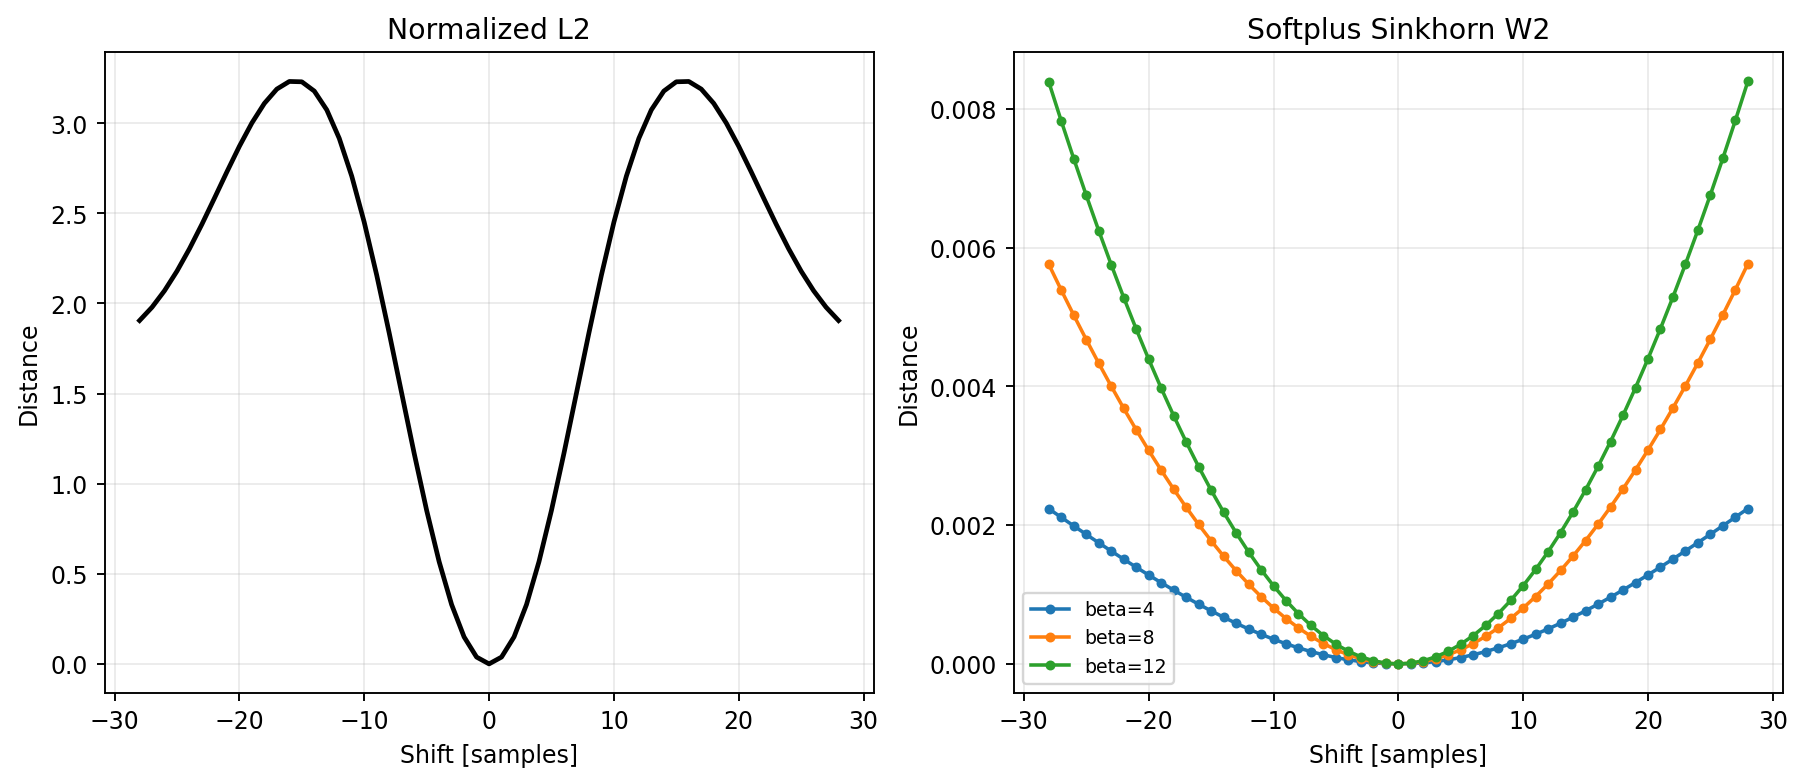<br>
<figcaption><em>Figure 7. Experiment 048 Wasserstein gate test. W2 behaves well on timing-shift examples, validating it as a diagnostic for that failure mode.</em></figcaption>
</figure>

<figure>
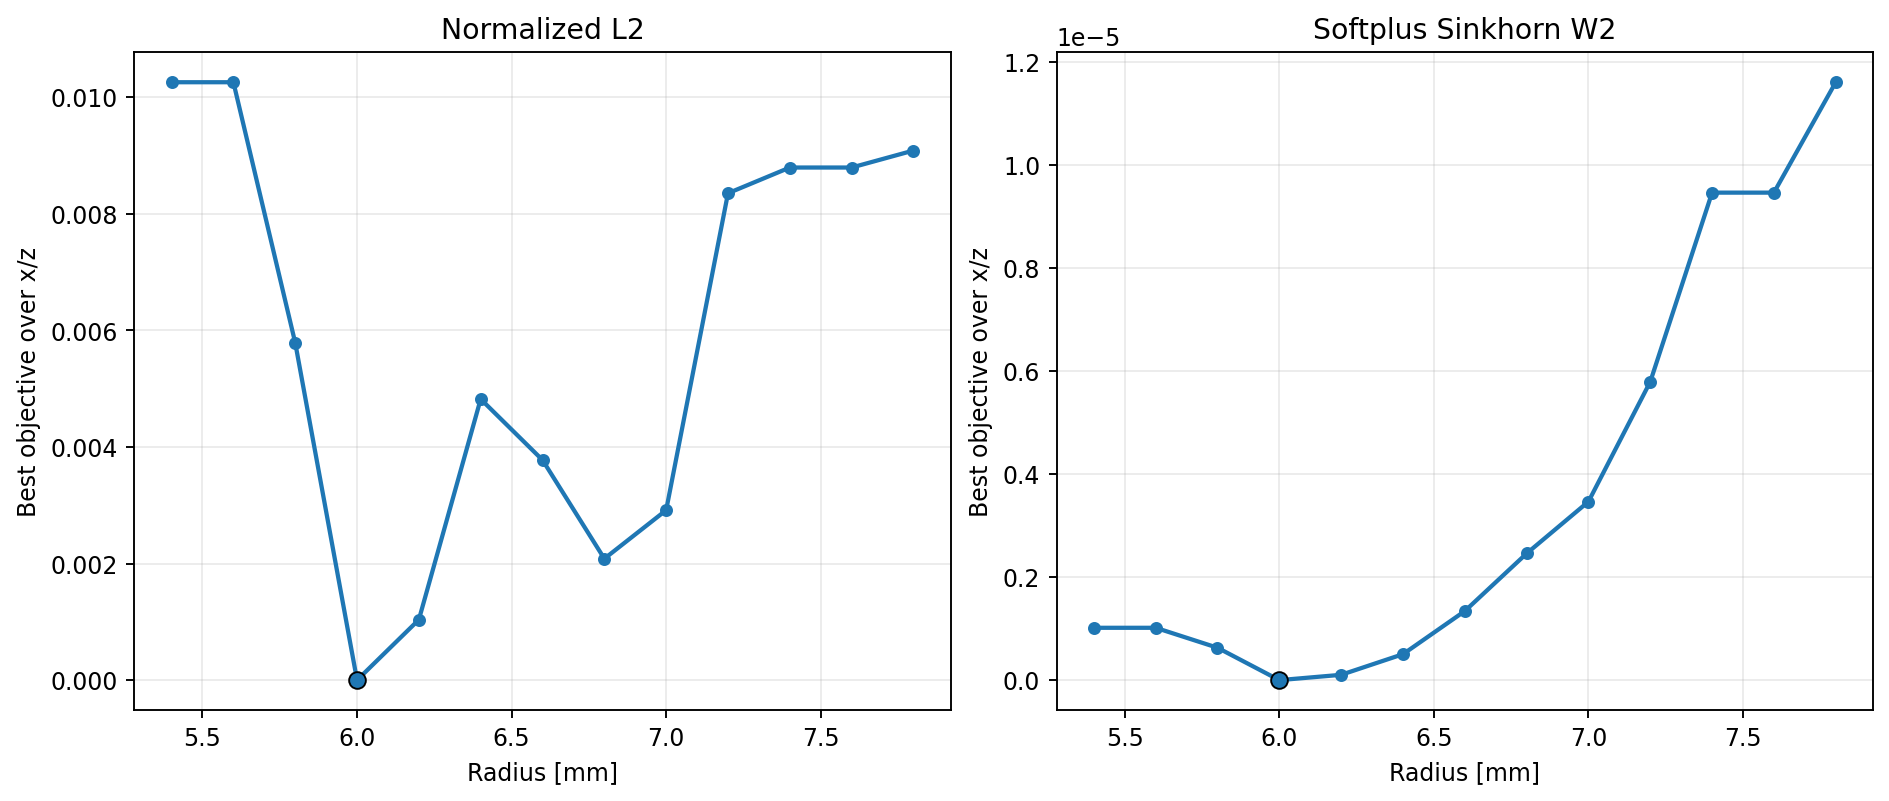<br>
<figcaption><em>Figure 8. Experiment 051 W2 radius landscape. On the actual radius task, W2 loses the amplitude detail needed for sizing and is not the production radius objective.</em></figcaption>
</figure>


<figure>
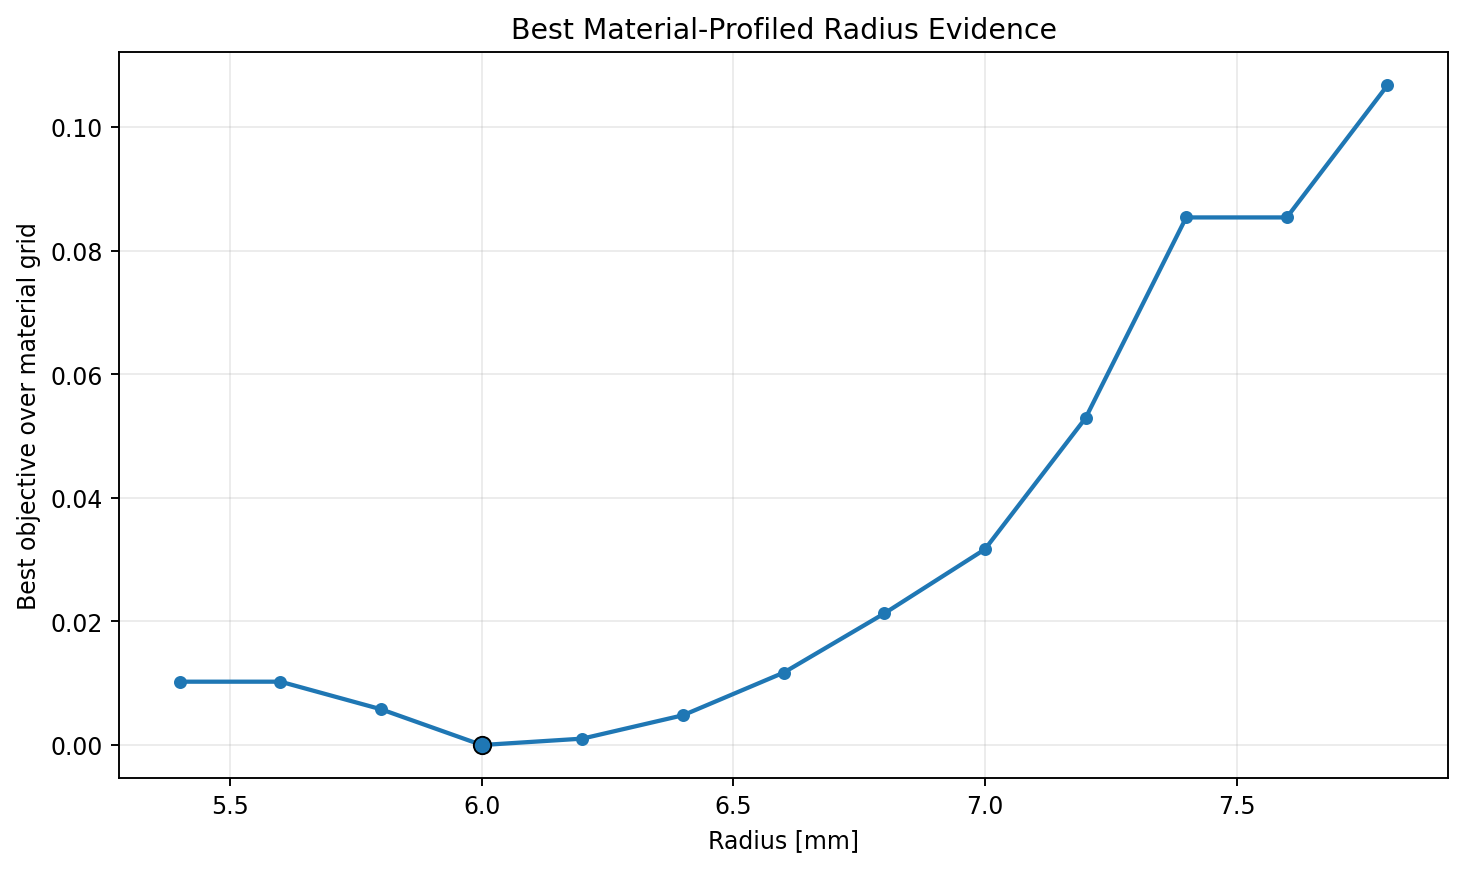<br>
<figcaption><em>Figure 11. Experiment 056 material tradeoff. Material variation does not explain the radius bias, so free material parameters were not added to the production size optimizer.</em></figcaption>
</figure>


## 4. Principal Finding: Source-Wavelet Mismatch

Experiments 052-055 isolate the most important radius failure mode. When the observed radar pulse differs from the pulse assumed by inversion, the optimizer can compensate by choosing a wrong radius. The failure occurs for modest changes in pulse amplitude, time zero, or center frequency.

The solution is source profiling. At each candidate geometry, the objective also fits pulse amplitude, time shift, and center-frequency scale. Experiment 055 shows the failure curves collapsing back to the correct radius minimum after those nuisance parameters are included.


<figure>
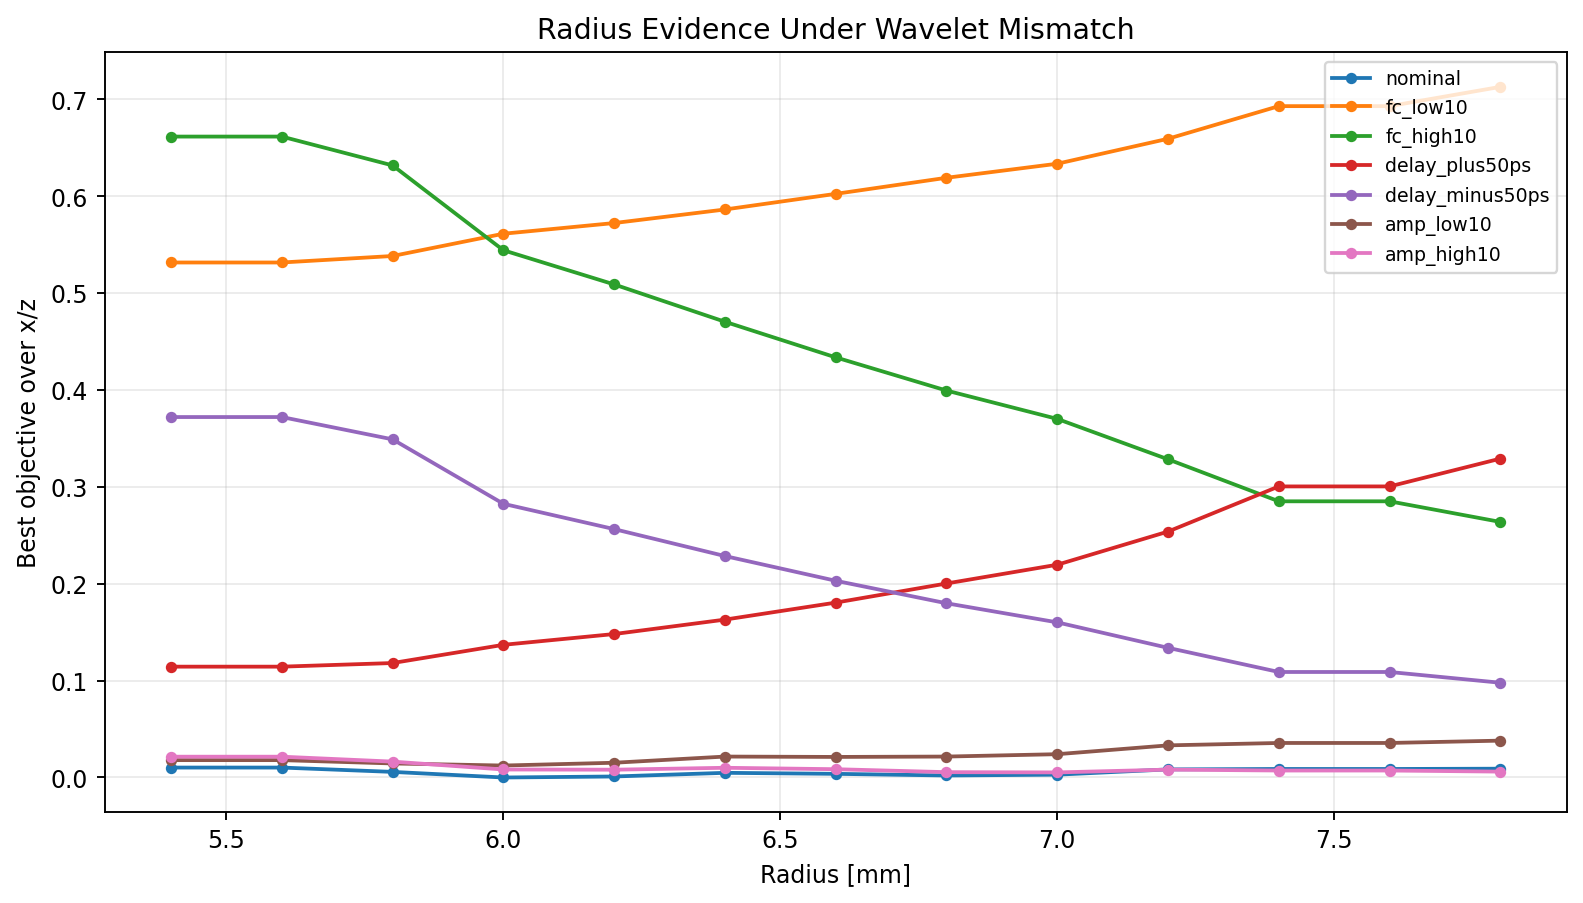<br>
<figcaption><em>Figure 9. Experiment 052 source-mismatch failure. Small pulse amplitude, timing, and center-frequency errors can push the recovered radius away from truth when the source pulse is fixed.</em></figcaption>
</figure>

<figure>
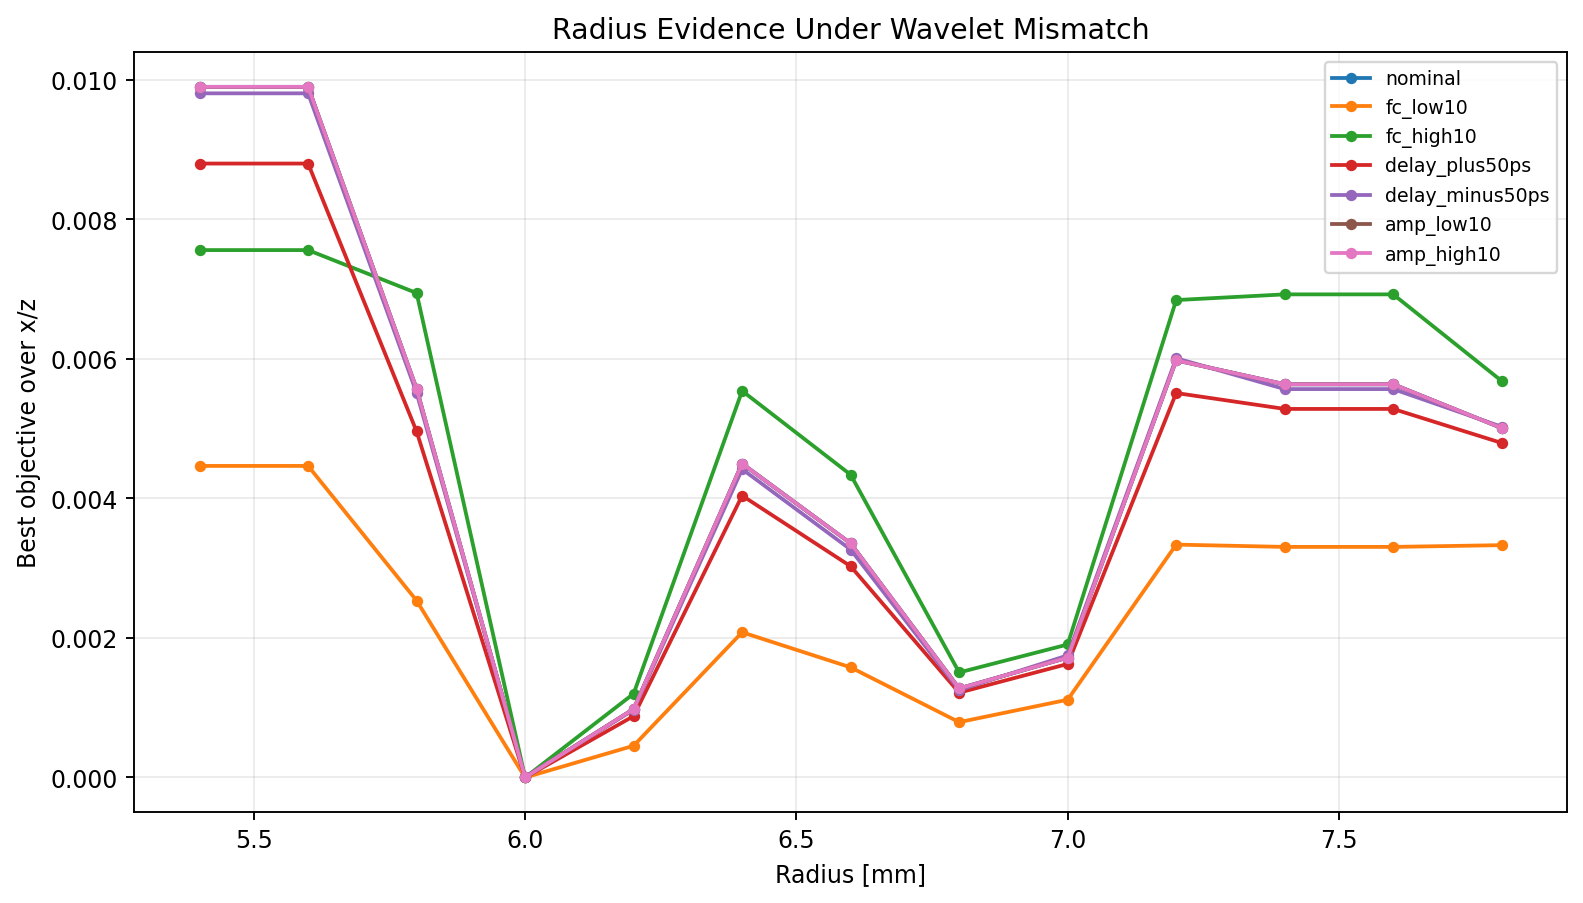<br>
<figcaption><em>Figure 10. Experiment 055 source-profiled fix. Solving for amplitude, time shift, and center-frequency scale as nuisance parameters restores the true-radius minimum.</em></figcaption>
</figure>


## 5. Multi-Rebar Confidence Reporting

After the source-profiled single-rebar branch, the archive moves to multiple bars. Neighboring bars interfere with one another, so the correct point estimate can still have a weak margin over a nearby alternative. Experiment 080 represents the shift from point-estimate reporting to confidence-aware reporting.

This is a methodological milestone. The pipeline reports a confidence label and an ambiguity interval, not just the best radius. The archive includes a 24-case replication in which the point estimates are correct but most cases are intentionally labeled weak because the data support a narrow interval rather than a sharply separated value.


<figure>
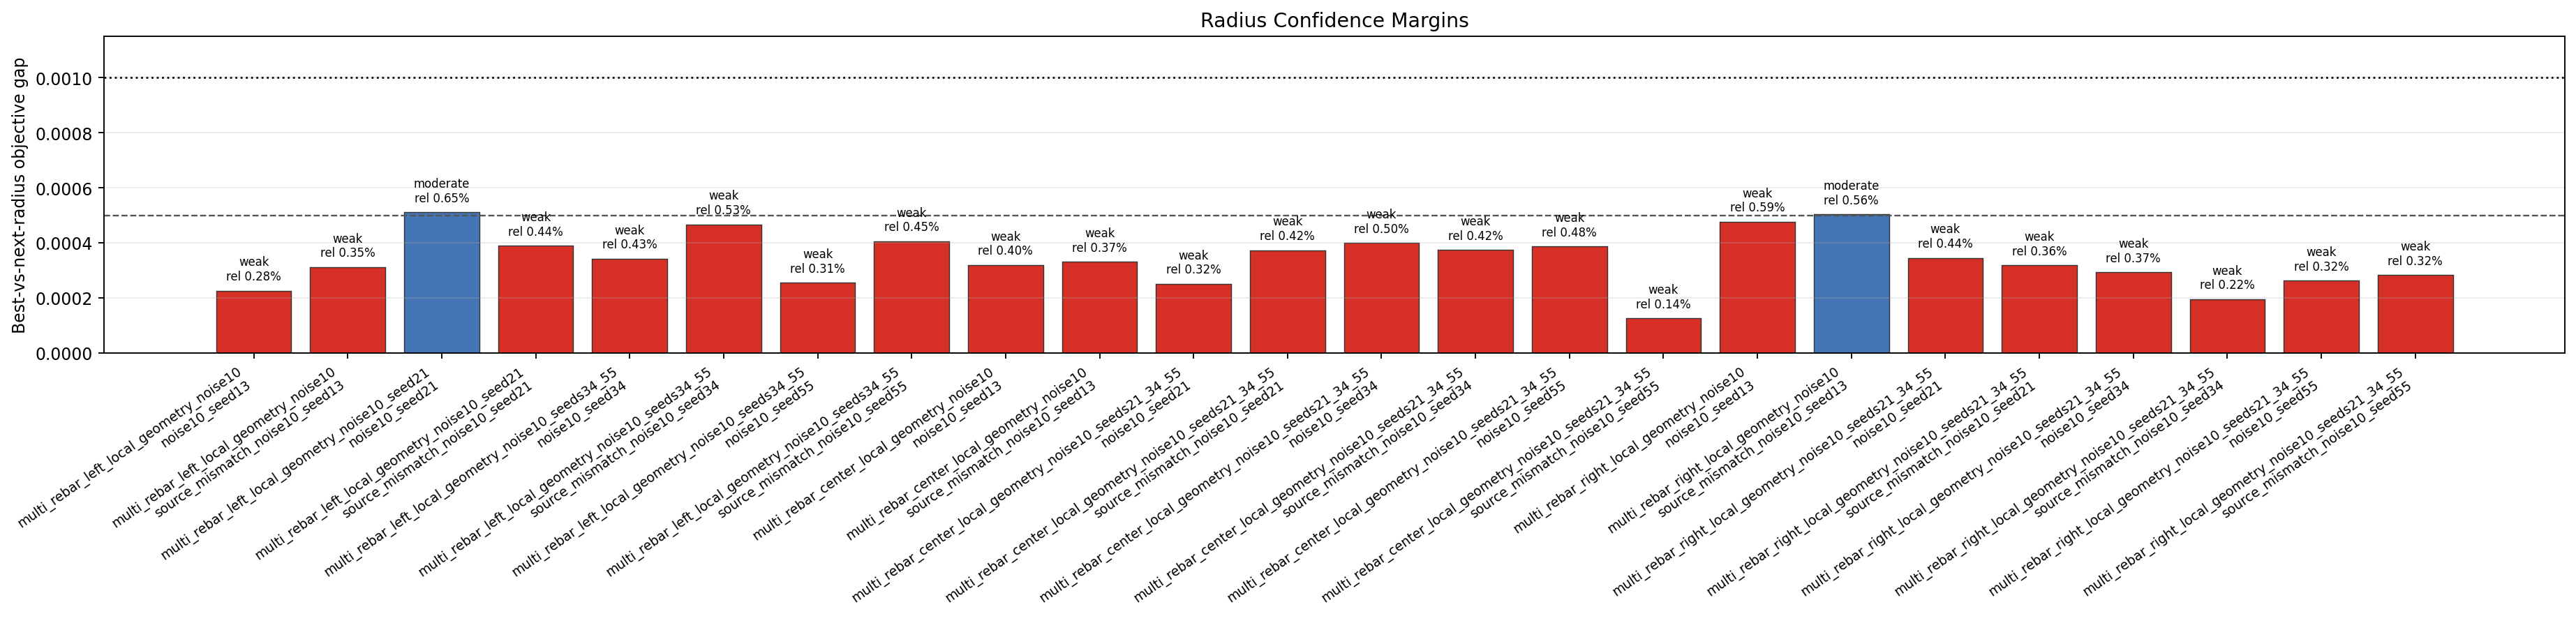<br>
<figcaption><em>Figure 12. Experiment 080 confidence and ambiguity reporting. Correct point estimates can have thin margins, so confidence labels and ambiguity intervals became part of the reported result.</em></figcaption>
</figure>


## 6. Detection-to-Inversion Pipeline

The next milestone removes the assumption that target locations are known. The detector operates directly on the B-scan: it suppresses background structure, builds an energy image, and scores hyperbola-like candidate positions. The single-rebar benchmark in experiment 112 covers 48 scenarios and reports 48 detections and 48 hits.

Detection then feeds staged refinement. Experiment 118 is a representative packaged run: about 546 s end to end, with approximately 16 s for detection, 282 s for the coarse screen, and 247 s for fine polish. Later high-band and material-uncertainty packages show how the pipeline reports when a point estimate remains correct but the confidence interval widens.


<figure>
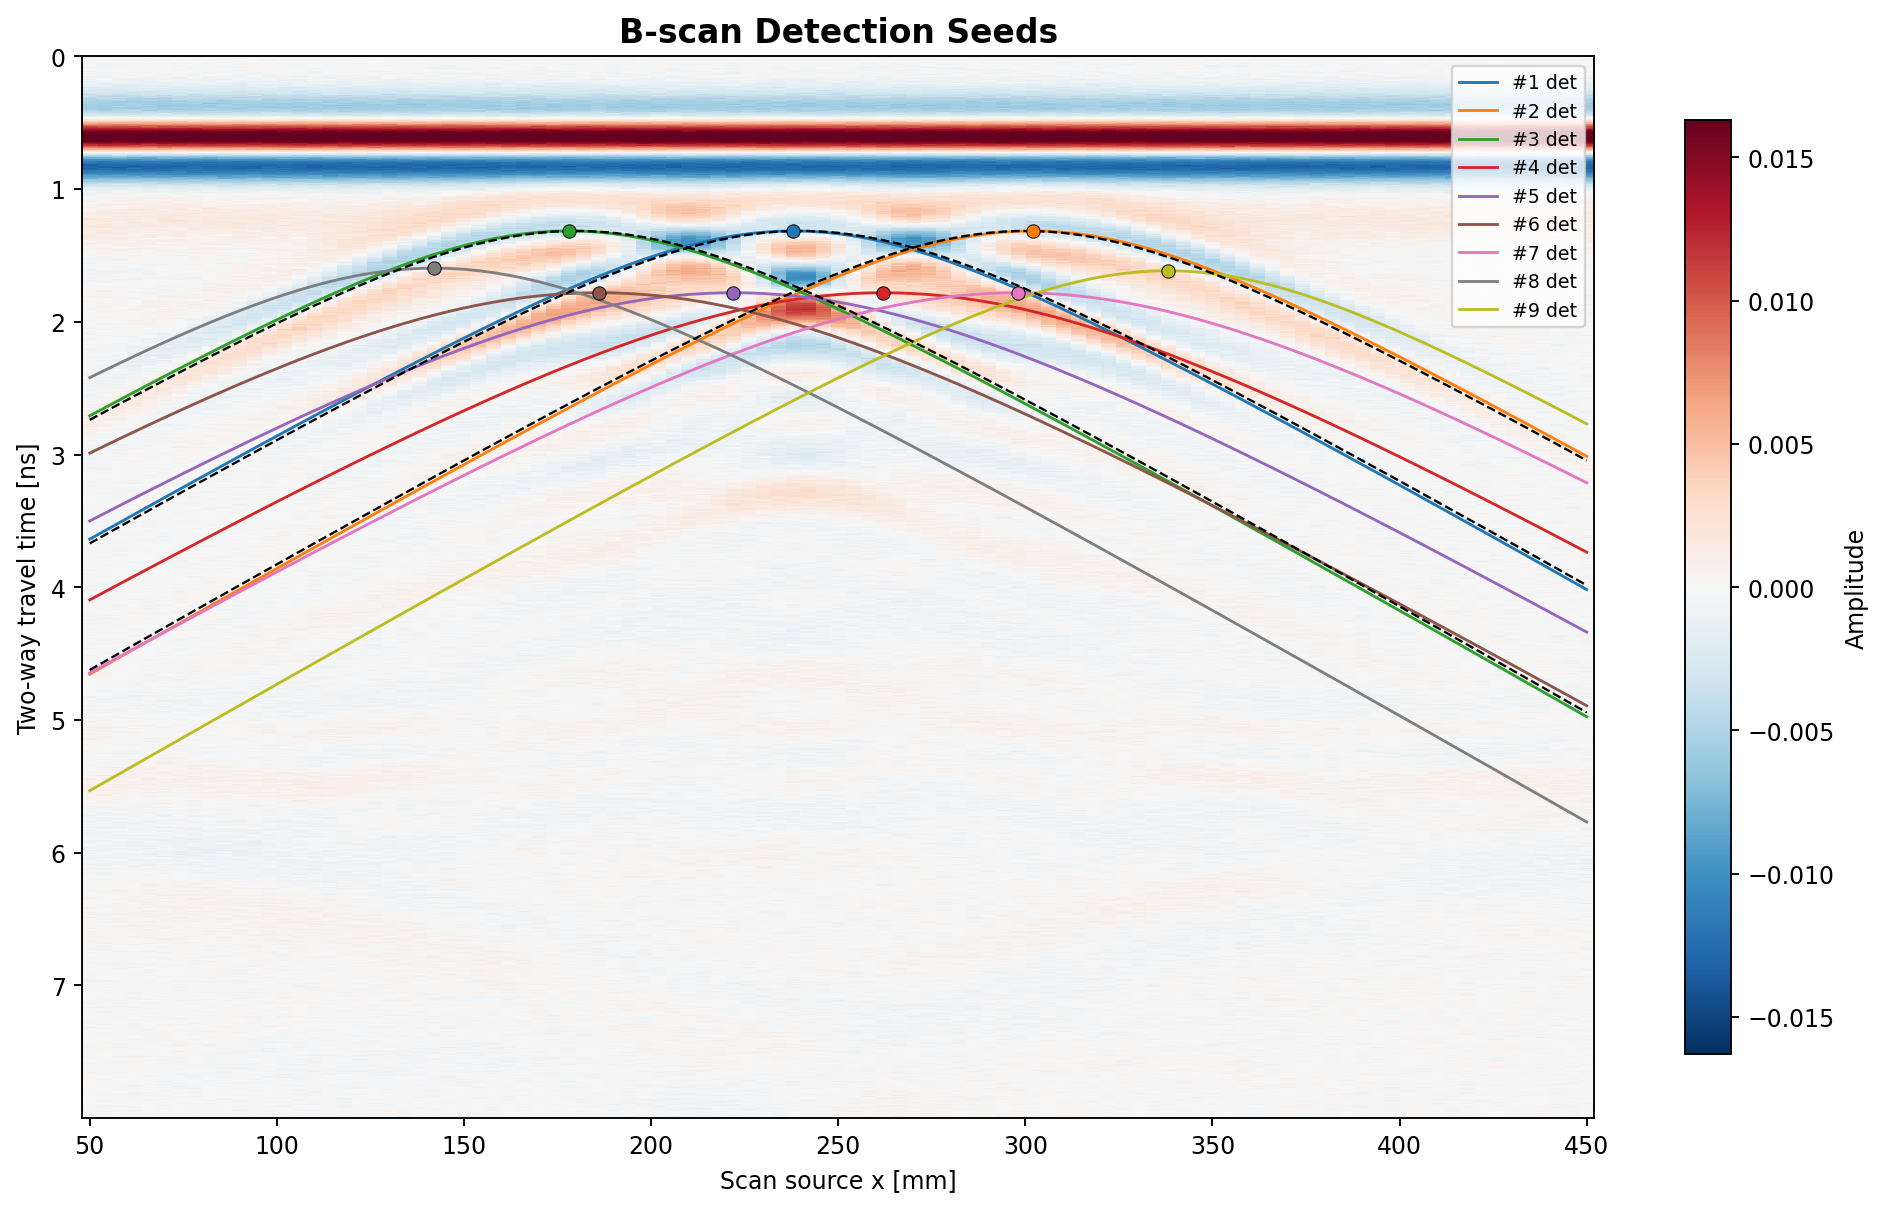<br>
<figcaption><em>Figure 13. Experiment 114 close-spacing detector overlay. The detector identifies seed windows in a noisy, source-mismatched multi-rebar B-scan.</em></figcaption>
</figure>

<figure>
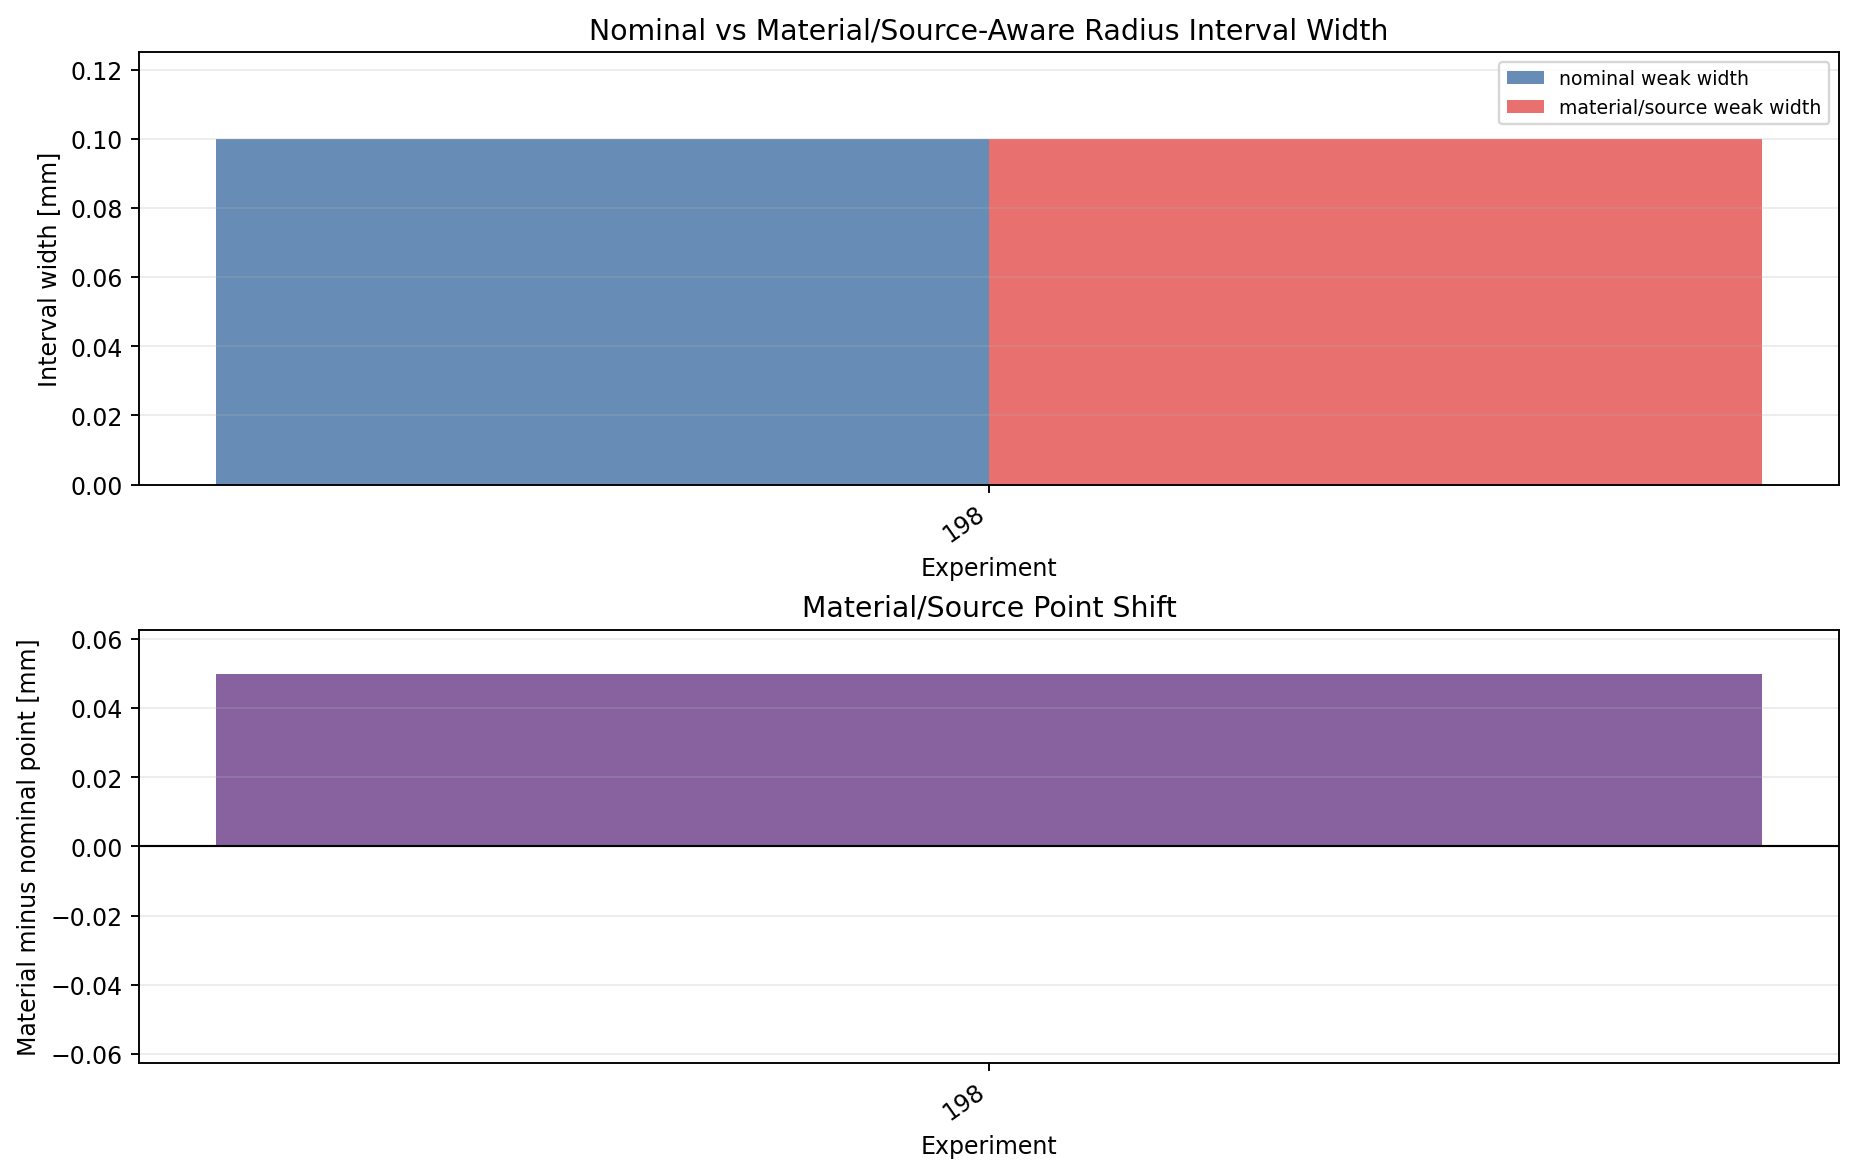<br>
<figcaption><em>Figure 14. Experiment 199 high-band and material-uncertainty summary. Higher-frequency acquisition improves radius confidence, while material uncertainty is tracked explicitly.</em></figcaption>
</figure>


## 7. Variable-Radius Close-Spacing Branch

The current research frontier is three bars with different radii in close spacing. This branch is difficult because position errors and radius errors can trade off. The archive shows that a joint size search succeeds when positions are fixed to truth, but can prefer inflated sizes when positions are fixed to imperfect detector seeds.

The staged policy is therefore: detect, assign one seed per physical target, correct position first, then estimate radius at the corrected geometry. Experiment 257 summarizes this staged variable-radius pipeline across seeds and shows how the stage order reduces errors.


<figure>
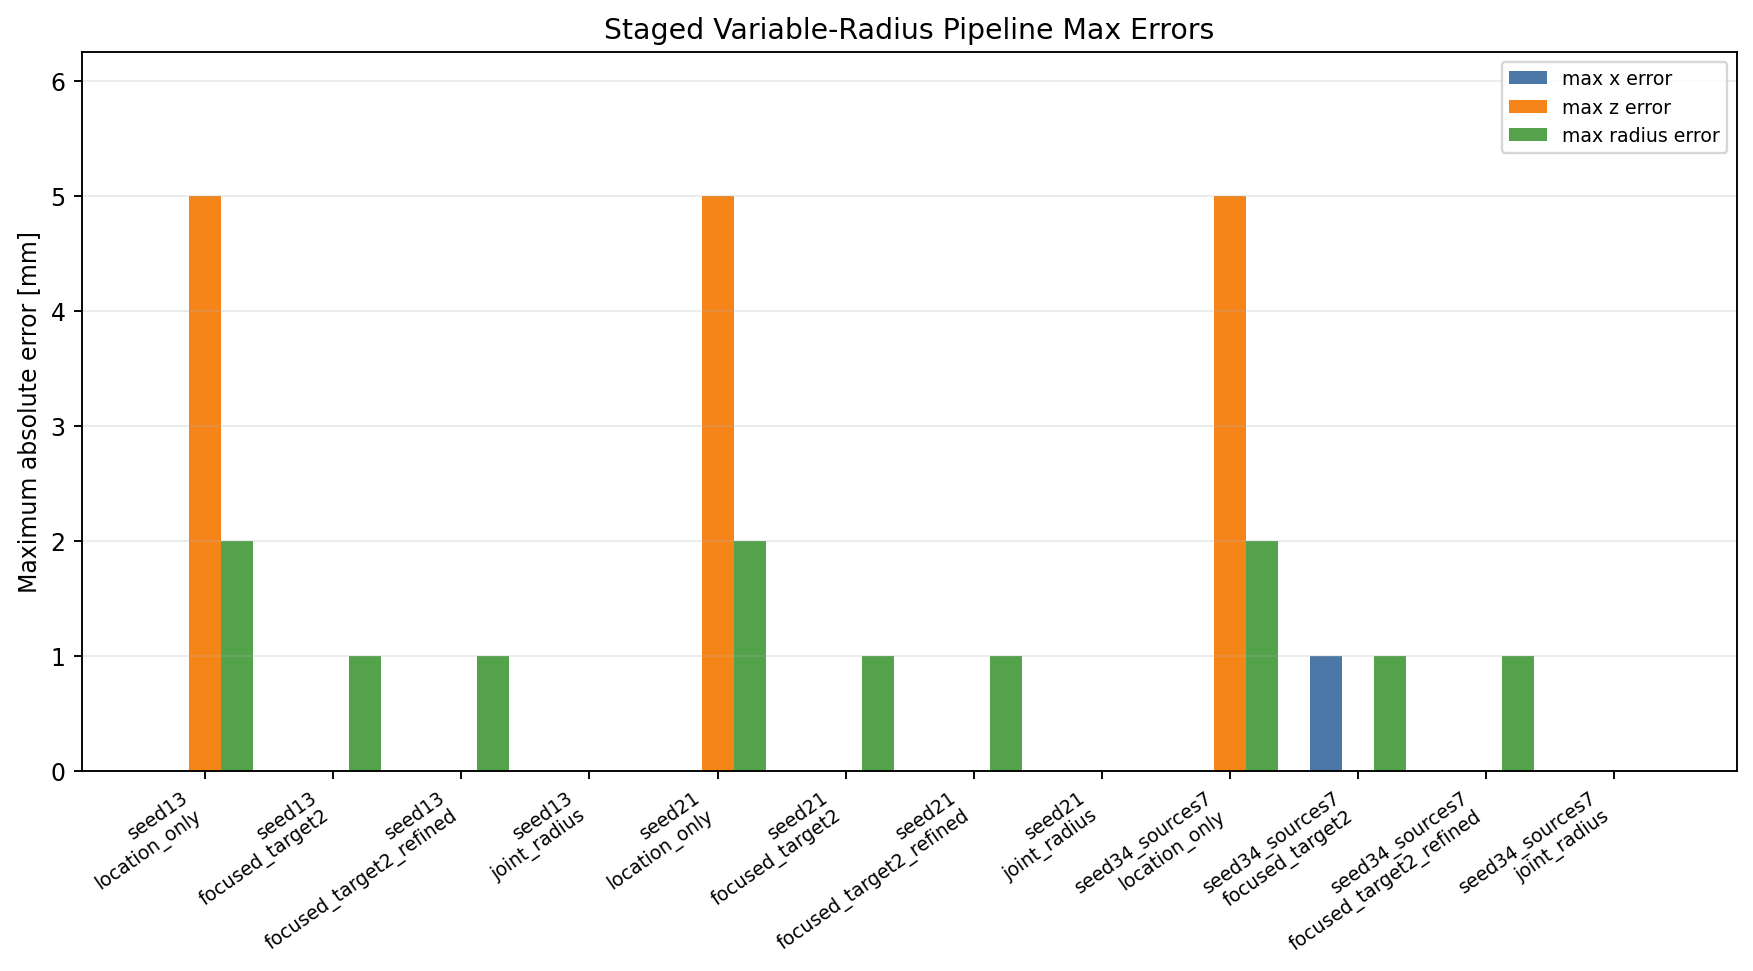<br>
<figcaption><em>Figure 15. Experiment 257 variable-radius staged-pipeline summary. Correcting position before reading size prevents the search from inflating neighboring radii.</em></figcaption>
</figure>


## 8. Acquisition Design as Part of the Inversion

The latest branch treats measurement design as an inversion variable. Tight lateral spacing creates ambiguity that cannot be fixed honestly by lowering a confidence threshold. The archive therefore tests physical levers: source count, scan geometry, and transmitter/receiver offset.

The current evidence is:

- Experiment 263 maps the close-50 mm and close-60 mm lateral ambiguity threshold.
- Experiment 271 replicates the benefit of 40 mm Tx/Rx offset across seeds.
- Experiment 273 compares 20 mm and 40 mm Tx/Rx offset at five sources.
- Experiment 277 compares three, four, and five sources at 40 mm Tx/Rx for seed 34.
- Experiment 280 replicates the four-source, 40 mm Tx/Rx setting across seeds 13, 21, and 34.

The experiment 280 aggregate reports six rows, six truth-geometry matches, six strong confidence labels, no fallback warnings, and maximum ambiguity width of 0.0 mm in x, z, and radius.


<figure>
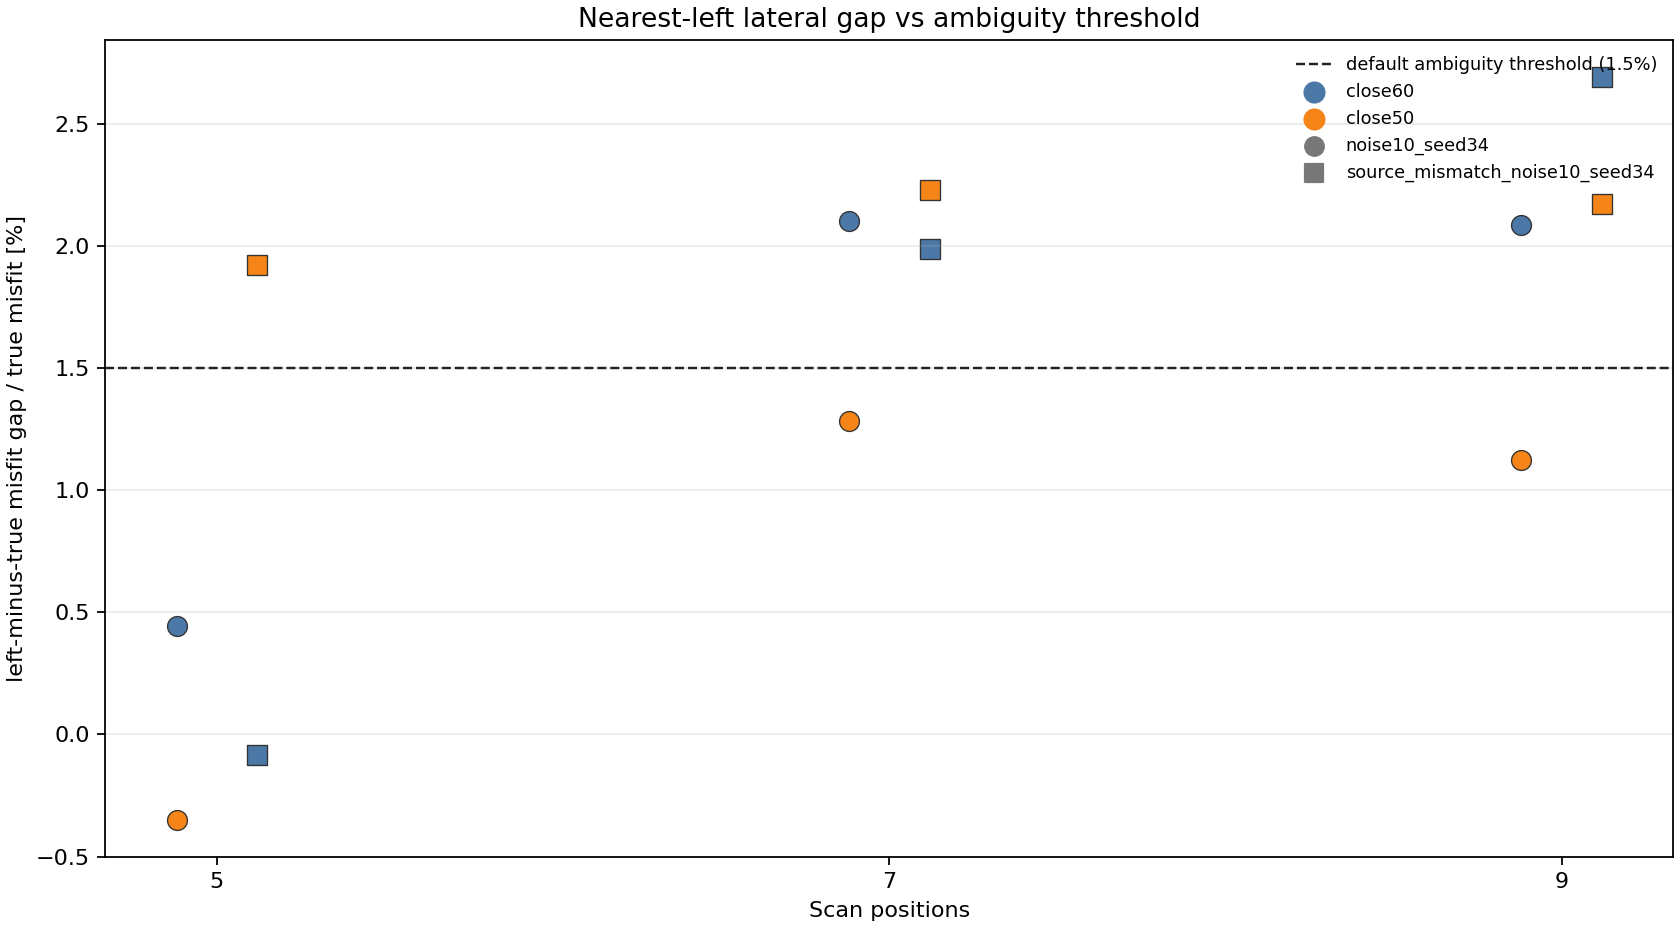<br>
<figcaption><em>Figure 16. Experiment 263 lateral gap threshold. Tight spacing produces a real lateral ambiguity unless the acquisition geometry provides enough separation.</em></figcaption>
</figure>

<figure>
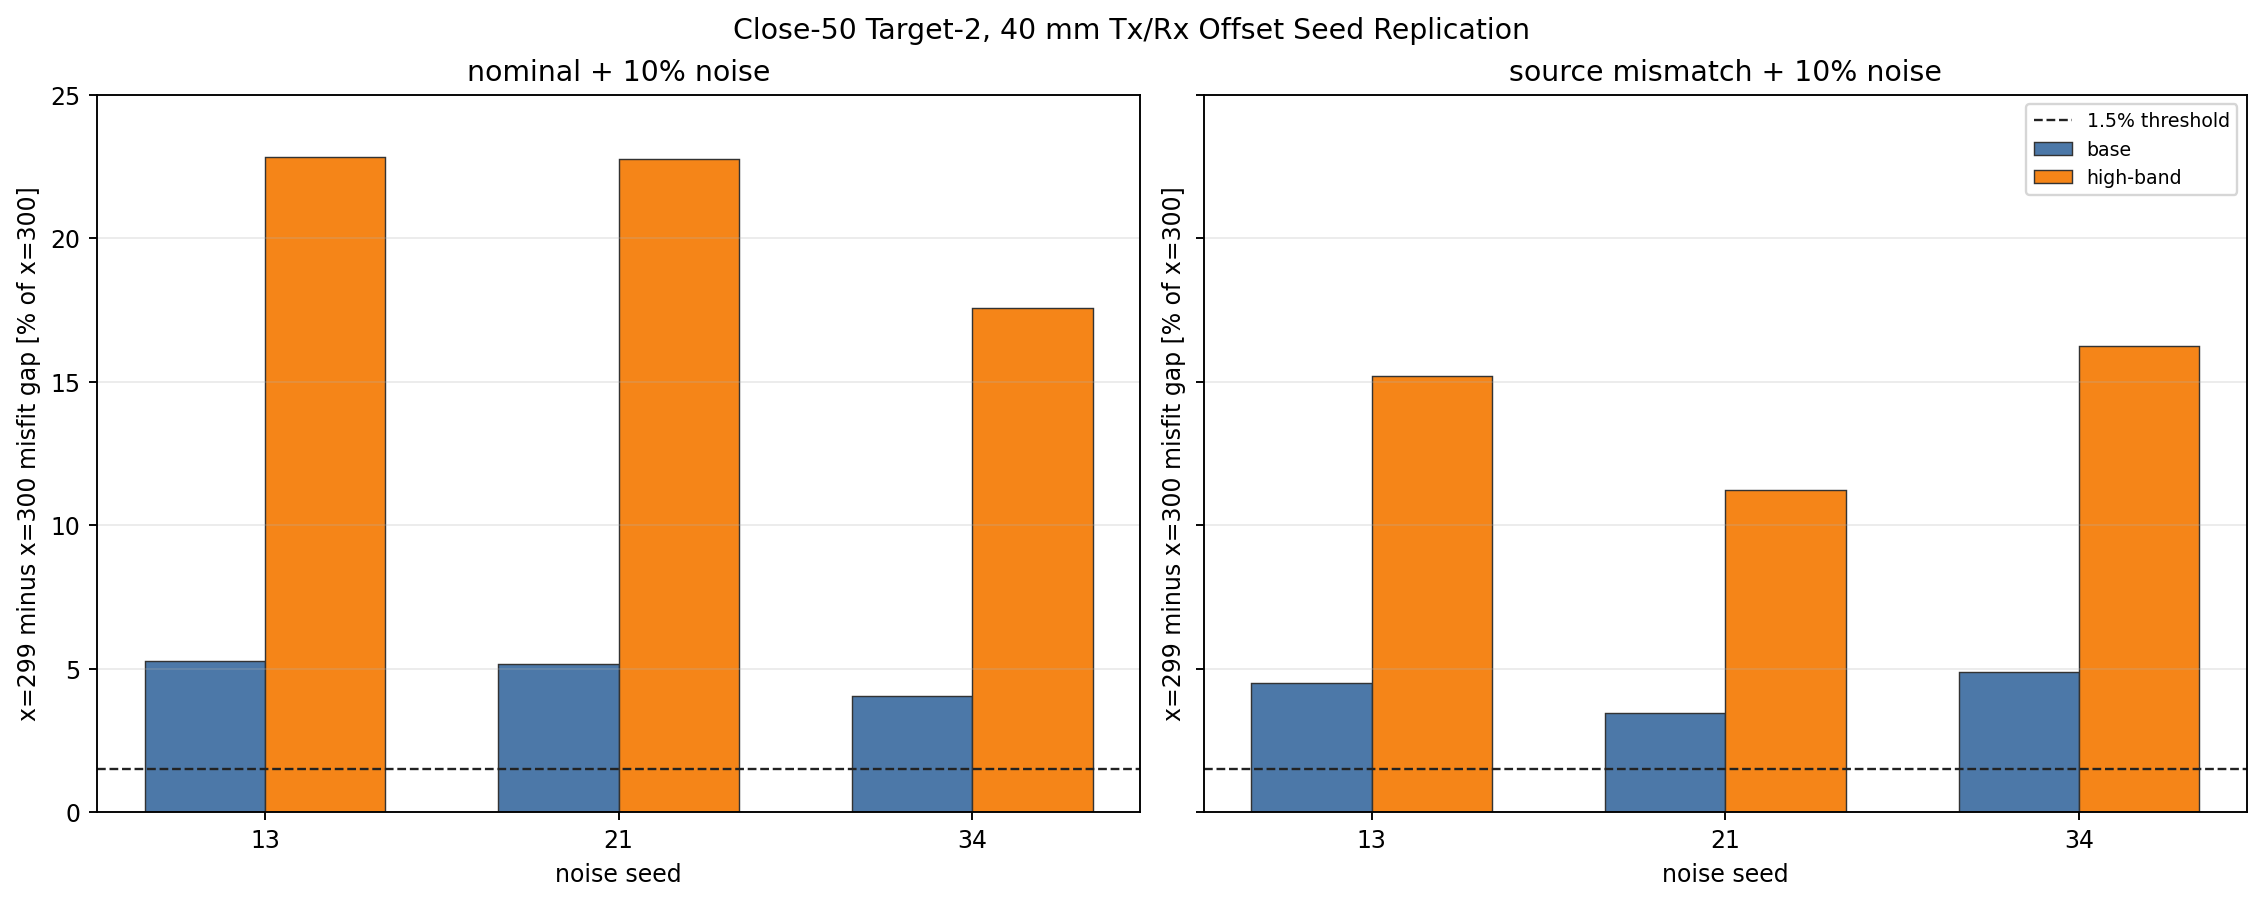<br>
<figcaption><em>Figure 17. Experiment 271 40 mm Tx/Rx replication. The wider transmitter/receiver offset separates the close-50 mm target across seeds.</em></figcaption>
</figure>


<figure>
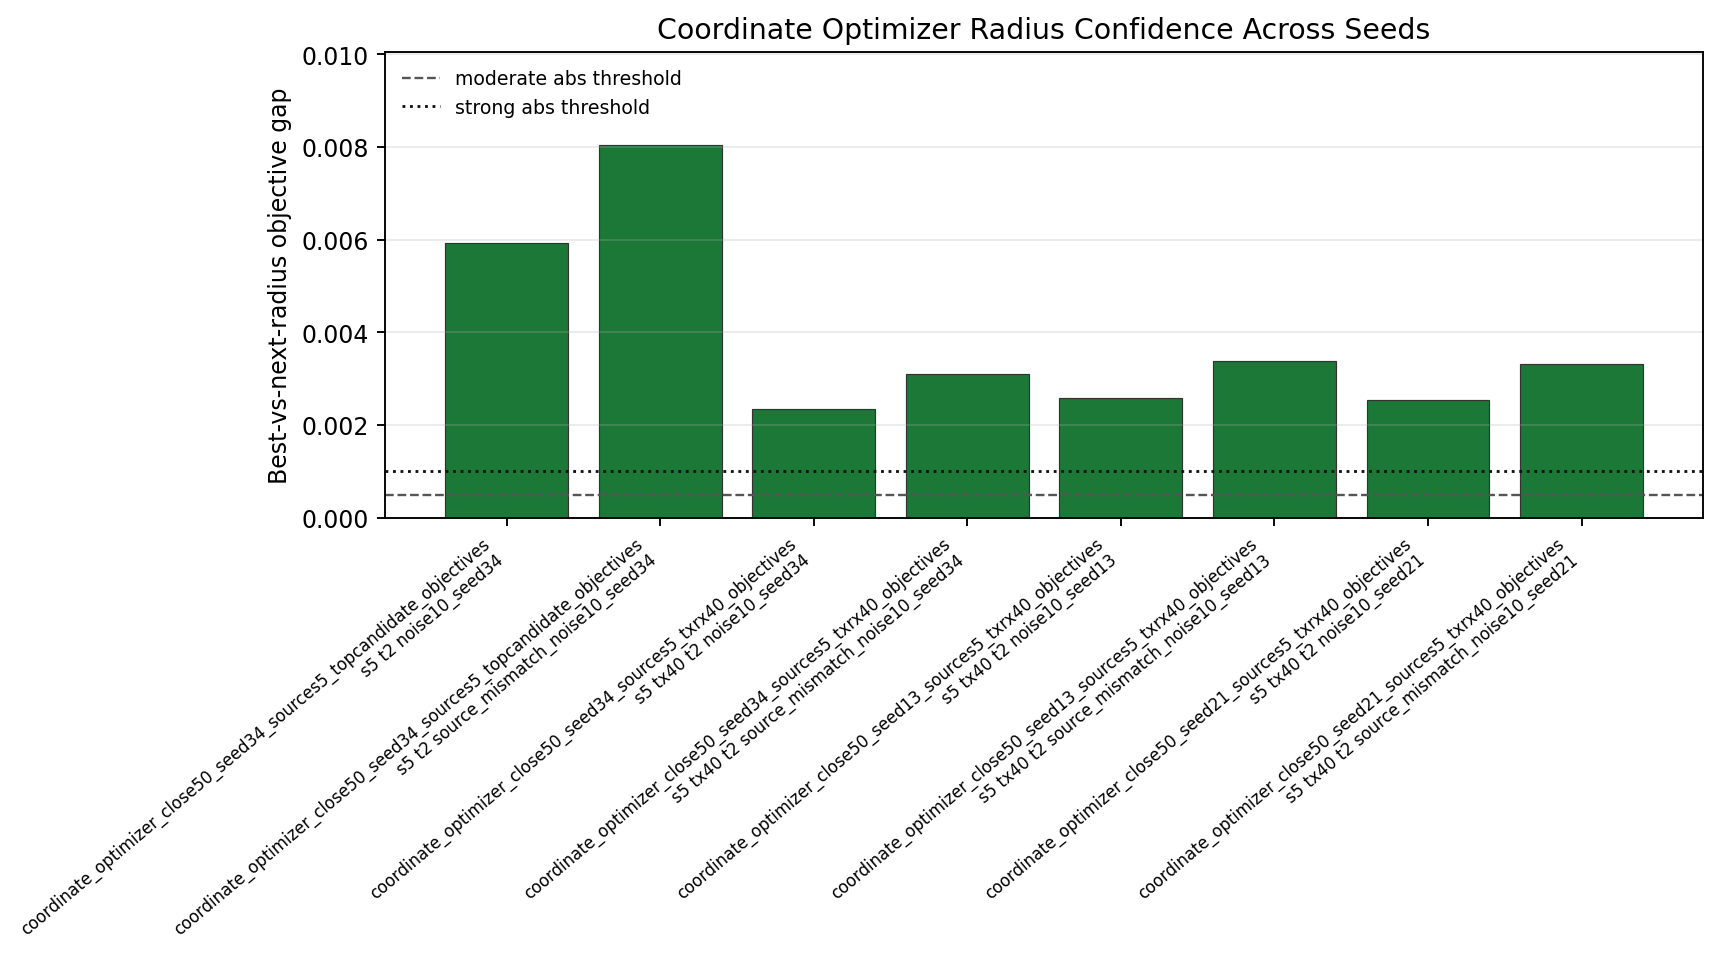<br>
<figcaption><em>Figure 18. Experiment 273 acquisition comparison. At five sources, the 40 mm Tx/Rx setting improves confidence relative to the narrower offset in the close-50 branch.</em></figcaption>
</figure>

<figure>
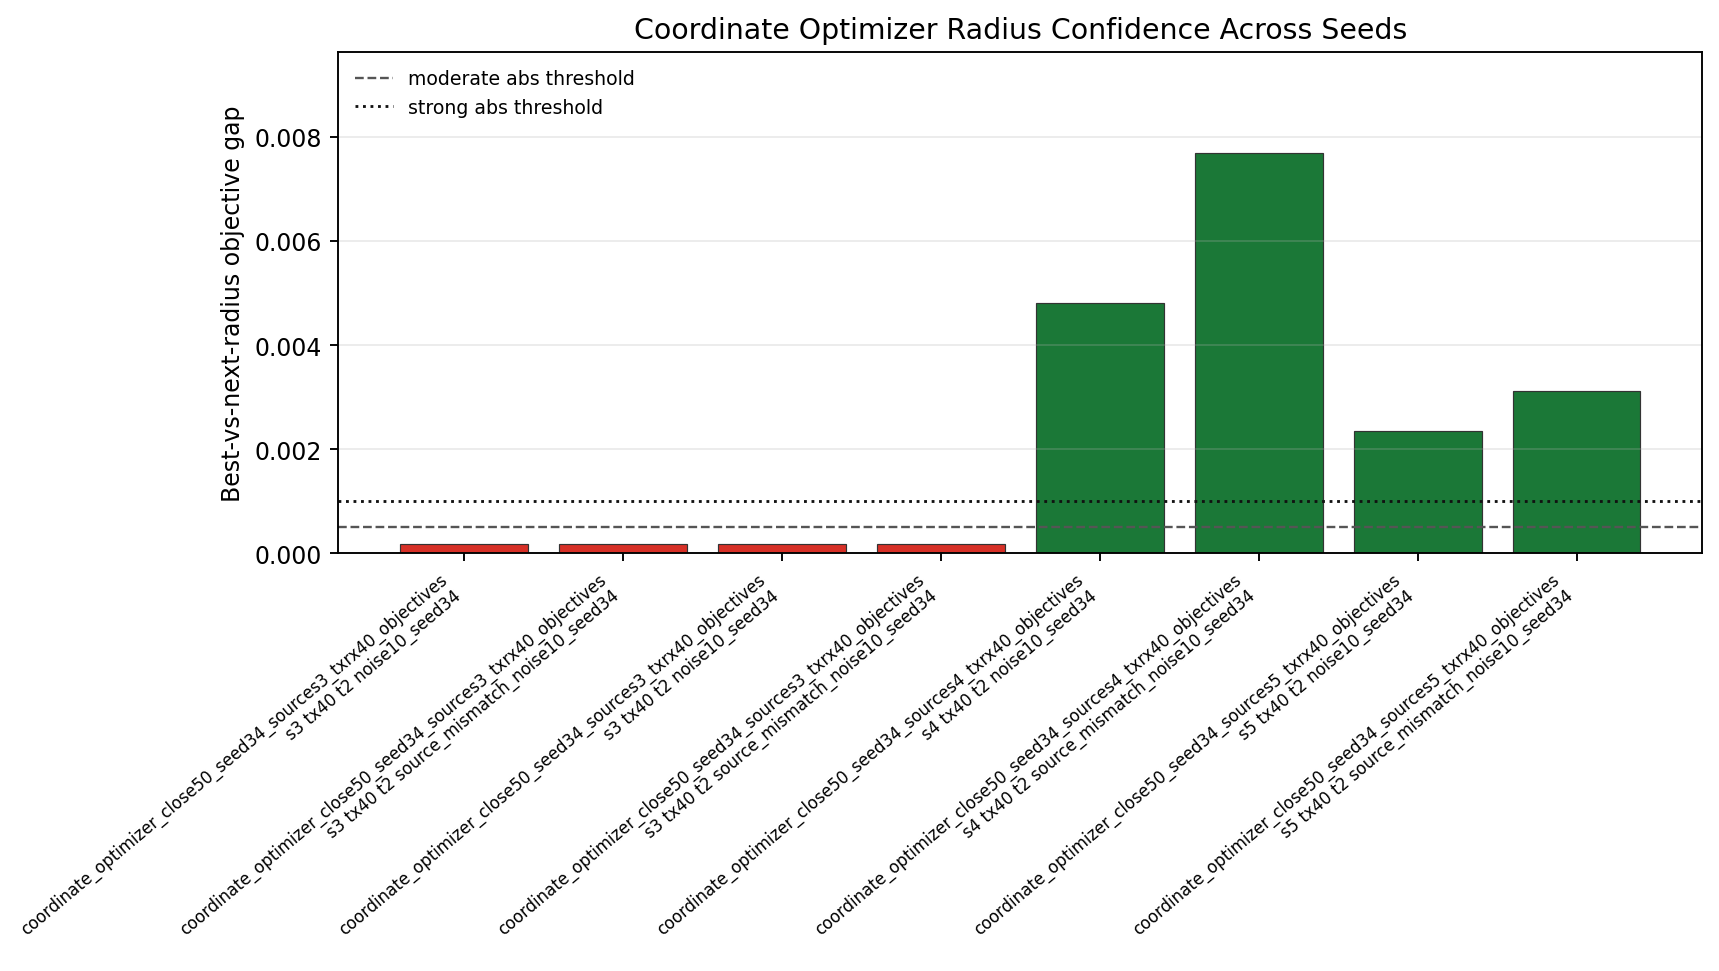<br>
<figcaption><em>Figure 19. Experiment 277 source-count comparison at 40 mm Tx/Rx. Three sources remain weak for the hard target, while four and five sources resolve the seed-34 branch.</em></figcaption>
</figure>


<figure>
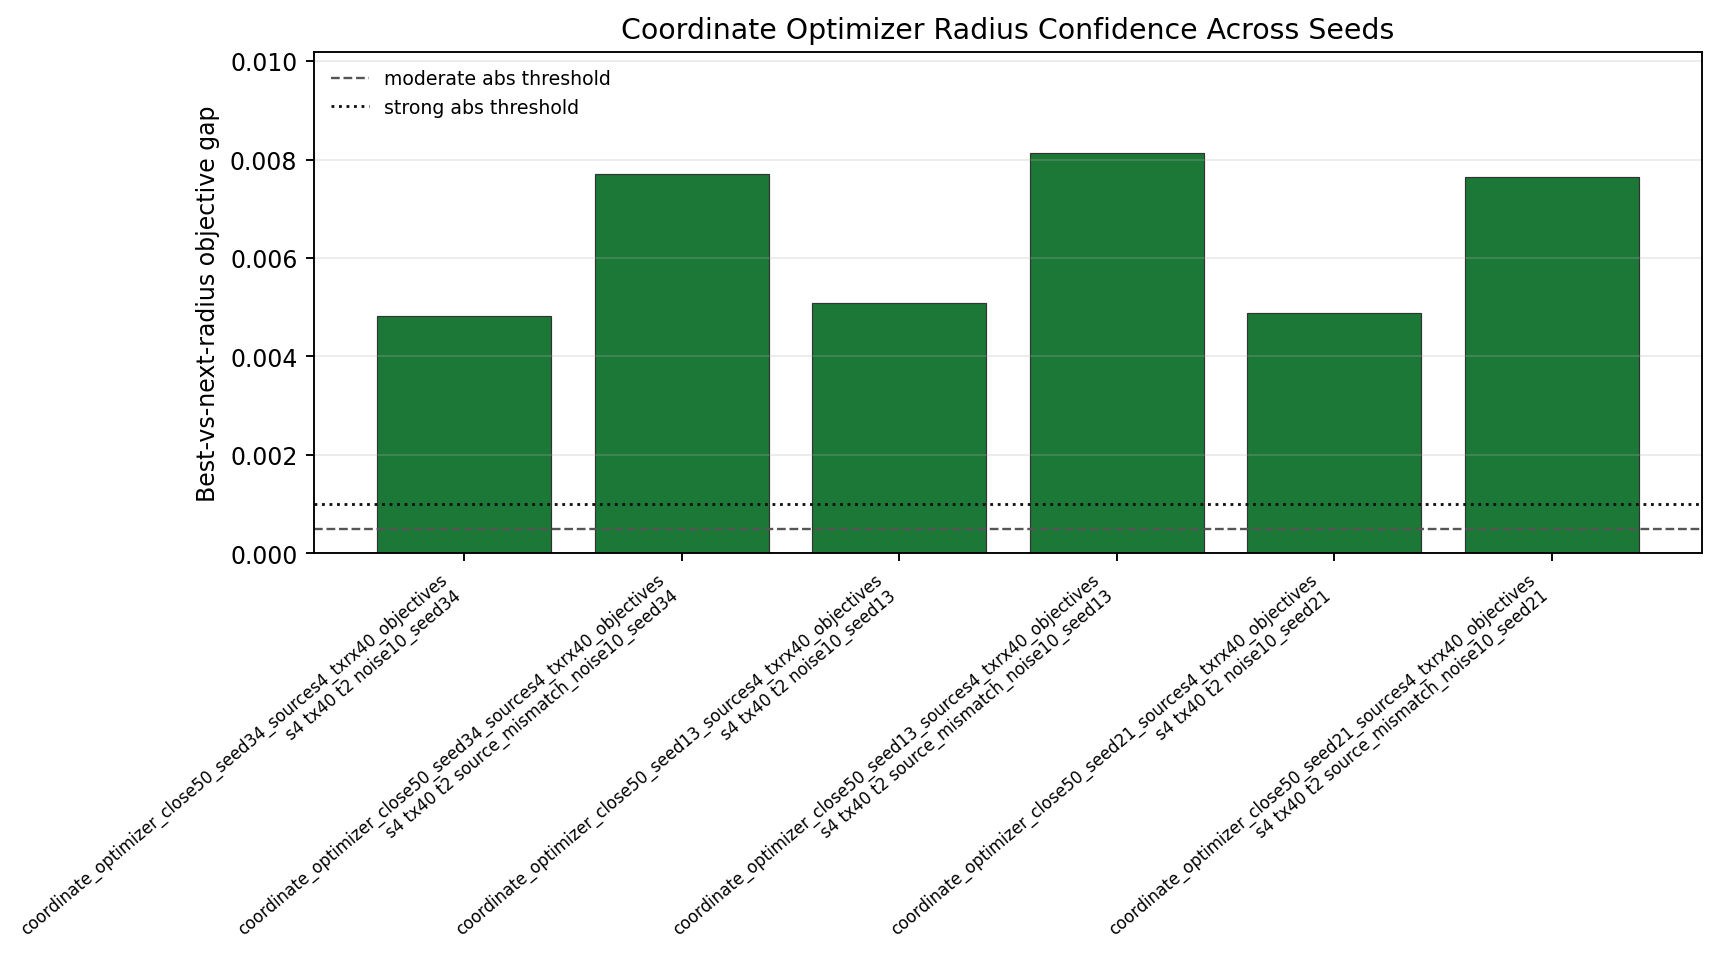<br>
<figcaption><em>Figure 20. Experiment 280 four-source 40 mm Tx/Rx seed aggregate. Across seeds 13, 21, and 34, all six rows recover truth with strong labels.</em></figcaption>
</figure>

<figure>
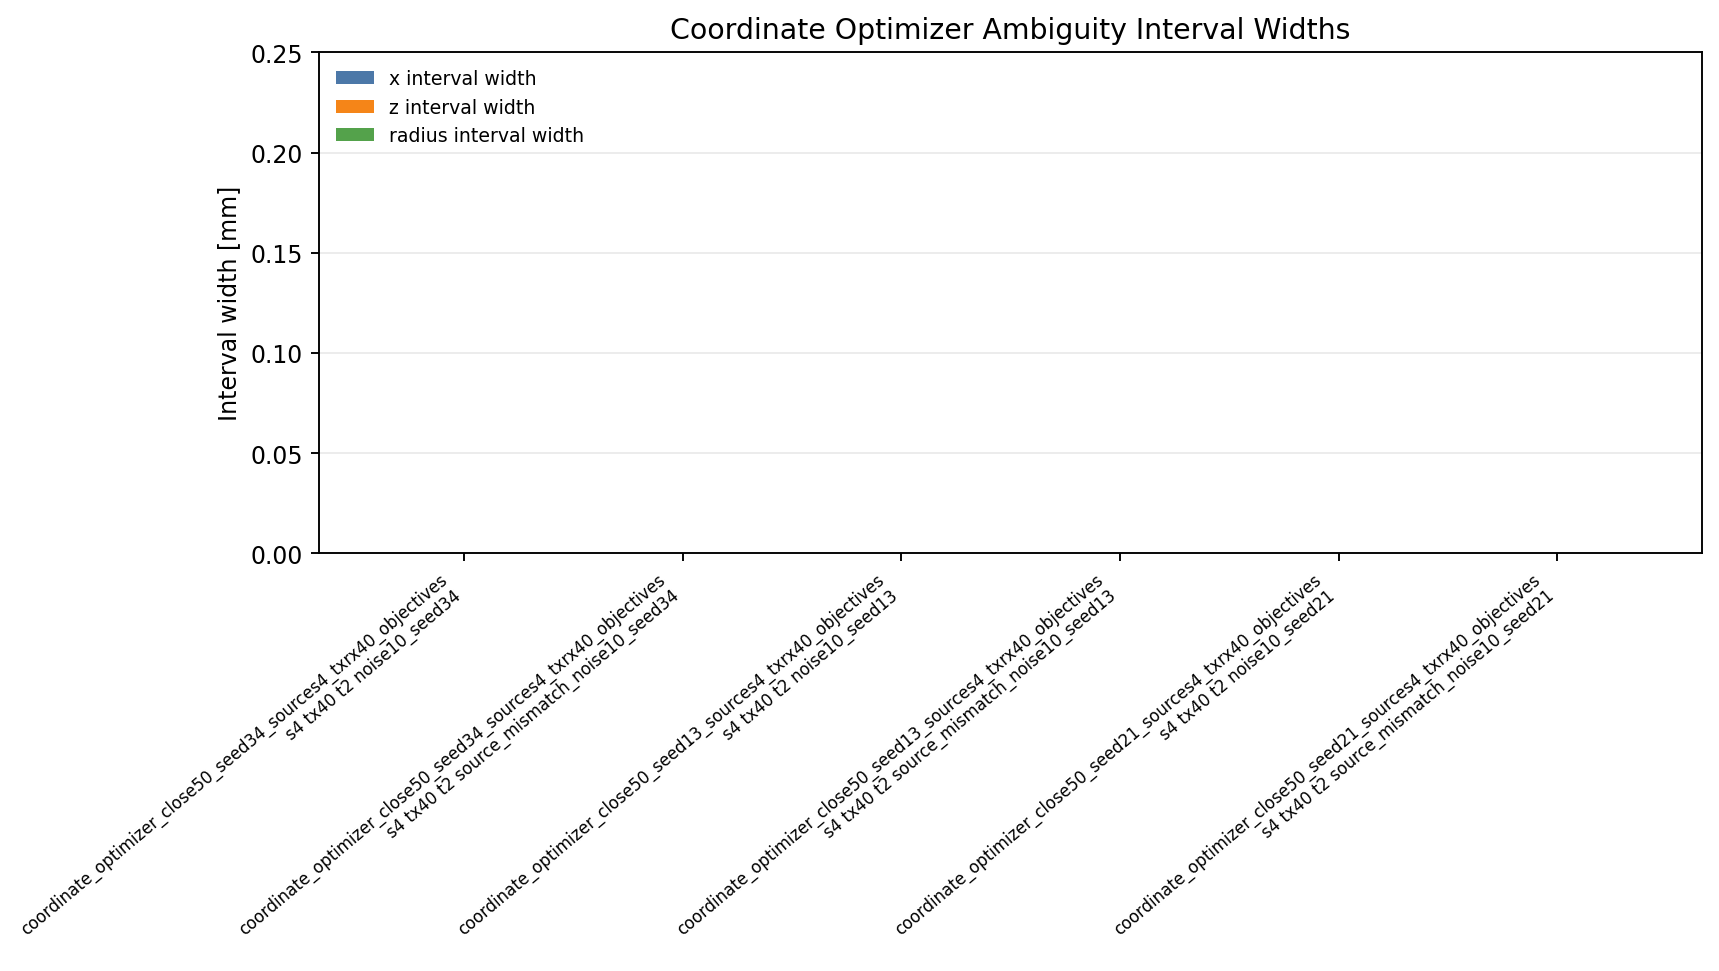<br>
<figcaption><em>Figure 21. Experiment 280 ambiguity widths. The four-source 40 mm Tx/Rx replicate reports zero lateral, depth, and radius ambiguity width for the tested hard-target cases.</em></figcaption>
</figure>


## 9. Computational Platform and Runtime Cost

The production sweeps were run GPU-first on an NVIDIA DGX Spark / GB10 system. Small CPU smoke diagnostics also exist in the numbered archive, but the computationally intensive FDTD sweeps use the GPU backend.

The practical FDTD cost in the current inversion workflow is about **1 second per transmit position**, or about **5 seconds for a 5-position local B-scan per frequency band**. This comes from numbered experiment logs: experiment 057 evaluates 12 five-position B-scans in 58.8 s, and experiment 058 evaluates 156 candidate/source-scale B-scan solves in 771.0 s.

Representative measured runtimes from `outputs/experiments` are:

| Operation | Experiment evidence | Scale | Wall time |
|---|---|---:|---:|
| Full local B-scan solve | 057/058 | 5 positions, one band | ~5 s |
| Detection benchmark | 112 | 48 scenarios | 242 s |
| Detection -> coarse -> fine | 118 | staged package | 546 s |
| Coarse screen | 118 | 77 candidates | 282 s |
| Fine polish | 118 | 15 candidates | 247 s |
| Four-source close-50, 40 mm Tx/Rx | 276, 278, 279 | 3 seeds, 2 cases each | about 21-22 min per seed |
| Four-source close-50, 30 mm Tx/Rx | 281-283 | 3 seeds, 2 cases each | about 21-22 min per seed |

The longer wall times come from deliberate sweeps over candidate geometry, source-profile nuisance parameters, frequency bands, and noise seeds. The cost is therefore dominated by how many B-scan solves are evaluated, not by a single unusually slow FDTD simulation.


## 10. Experiment Archive Snapshot

The archive currently contains 283 numbered experiment folders under `outputs/experiments`, and more than 560 figure or animation files inside that same experiment archive.

| Milestone | Main question | Experiment range | Outcome |
|---|---|---:|---|
| Single-rebar baseline | Can position, depth, and radius be recovered on controlled synthetic data? | 001-023 | Baseline recovery works; radius needs polish and margin reporting. |
| Strategy tests | Which method ideas actually help radius? | 024-062 | Source profiling is decisive; W2/material branches are diagnostic or rejected for radius. |
| Multi-rebar confidence | Can several bars be estimated without overstating precision? | 063-106 | Confidence labels and ambiguity intervals become mandatory outputs. |
| Detection-to-inversion | Can the pipeline start from B-scans without known locations? | 107-201 | Detector benchmark succeeds; staged refinement controls cost. |
| Variable-radius acquisition design | Can close, differently sized bars be resolved? | 202-283 | Position-before-size staging and 40 mm Tx/Rx offset resolve the hard branch tested so far. |


## 11. Capabilities and Limitations

**Established on 2-D synthetic experiment data:**

- FDTD forward modeling with B-scan and wavefield outputs.
- Single-bar recovery under controlled noise.
- Source-wavelet mismatch correction through nuisance-parameter profiling.
- Multi-bar confidence reporting with margins and ambiguity intervals.
- Detector-seeded refinement from B-scans.
- Variable-radius close-spacing recovery when position is corrected before size.
- Acquisition-design evidence showing that 40 mm Tx/Rx offset resolves the tested close-50 mm branch with four sources.

**Known limitations:**

- The results remain synthetic and two-dimensional.
- Field and laboratory B-scans are not yet part of the validation set.
- Shallow, thin bars can require interval reporting under noise and source mismatch.
- Sub-millimeter radius claims are limited by rasterization unless finer grids or subcell modeling are used carefully.
- The staged workflow still needs consolidation into a single reproducible runner.


## 12. Forward Plan

1. Package the staged workflow into one runner: detect -> assign -> locate -> focus -> size -> report.
2. Continue acquisition-design sweeps around Tx/Rx offset, source count, and high-band acquisition.
3. Calibrate confidence thresholds against repeated noise and source-mismatch trials.
4. Extend source and material nuisance modeling before moving to laboratory data.
5. Keep heavier WRI or neural parameterizations reserved for failure modes that explicit nuisance modeling cannot explain.


## 13. Figure Traceability

All embedded media in this v3 notebook are from `outputs/experiments`.

| Figure | Experiment-archive source path |
|---|---|
| Figure 1 | `outputs/experiments/023_single_rebar_grid1mm_noise10_coarsepolish_topk/figures/single_rebar_observed_bscan.png` |
| Figure 2 | `outputs/experiments/023_single_rebar_grid1mm_noise10_coarsepolish_topk/figures/single_rebar_model_comparison.png` |
| Figure 3 | `outputs/experiments/052_wavelet_mismatch_radius_exact/figures/true_nominal_wavefield.gif` |
| Figure 4 | `outputs/experiments/052_wavelet_mismatch_radius_exact/figures/delay_minus50ps_nominal_r7p8_muted_residual_backprop.gif` |
| Figure 5 | `outputs/experiments/043_pebd_spectrum_design_exact/figures/residual_spectra.png` |
| Figure 6 | `outputs/experiments/047_frequency_weight_radius_margin_noise10_seed13/figures/frequency_weight_radius_profiles.png` |
| Figure 7 | `outputs/experiments/048_trace_wasserstein_convexity_smoke/figures/trace_w2_convexity.png` |
| Figure 8 | `outputs/experiments/051_w2_landscape_exact_beta8_ds8/figures/w2_radius_profiles.png` |
| Figure 9 | `outputs/experiments/052_wavelet_mismatch_radius_exact/figures/wavelet_mismatch_radius_profiles.png` |
| Figure 10 | `outputs/experiments/055_wavelet_mismatch_radius_amp_time_freqfit/figures/wavelet_mismatch_radius_profiles.png` |
| Figure 11 | `outputs/experiments/056_material_tradeoff_fixed_xz_exact/figures/material_profiled_radius.png` |
| Figure 12 | `outputs/experiments/080_multi_rebar_stage7_ambiguity_interval_report/figures/candidate_confidence_margins.png` |
| Figure 13 | `outputs/experiments/114_detection_multi_rebar_close_spacing_source_mismatch_noise10/figures/detection_overlay.png` |
| Figure 14 | `outputs/experiments/199_packaged_highband_material_uncertainty_aggregate_178_198/figures/two_stage_material_uncertainty_summary.png` |
| Figure 15 | `outputs/experiments/257_variable_radius_staged_pipeline_seed13_21_34_sources7_refinement_summary/figures/staged_variable_radius_pipeline_errors.png` |
| Figure 16 | `outputs/experiments/263_lateral_gap_threshold_close50_vs_close60_summary/figures/lateral_neighbor_gap_thresholds.png` |
| Figure 17 | `outputs/experiments/271_close50_txrx40_seed_replication_summary/figures/txrx40_seed_gap_replication.png` |
| Figure 18 | `outputs/experiments/273_coordinate_confidence_aggregate_close50_txrx20_vs_txrx40_sources5/figures/coordinate_confidence_aggregate.png` |
| Figure 19 | `outputs/experiments/277_coordinate_confidence_aggregate_close50_txrx40_sources3_4_5_seed34/figures/coordinate_confidence_aggregate.png` |
| Figure 20 | `outputs/experiments/280_coordinate_confidence_close50_sources4_txrx40_seed_replicates/figures/coordinate_confidence_aggregate.png` |
| Figure 21 | `outputs/experiments/280_coordinate_confidence_close50_sources4_txrx40_seed_replicates/figures/coordinate_ambiguity_widths.png` |


## 14. Hardware Source Notes

Experiment evidence and all embedded media in this notebook come from `outputs/experiments`. Hardware specifications are based on the local run environment and NVIDIA's published DGX Spark / GB10 specifications:

- NVIDIA DGX Spark product page: https://www.nvidia.com/en-us/products/workstations/dgx-spark/
- NVIDIA DGX Spark User Guide PDF: https://docs.nvidia.com/dgx/dgx-spark/dgx-spark.pdf

---

*This notebook is self-contained: the experiment-archive figures and animations are embedded directly in the notebook.*
